# Toronto's Political Neighbourhoods — Interpreting Model 8F

This notebook picks up where `explore_neighbourhood_clusters.ipynb` left off. That notebook
built and compared many candidate clustering models of Toronto's 585 census tracts, using
their voting behaviour across three recent elections (the 2023 mayoral race, the 2025 Ontario
election, and the 2025 federal election). **This notebook does not re-run that model search.**
Its only job is to take the model that was chosen — **8F** — and interpret it in enough depth
to support a data-journalism piece on Toronto's political geography.

## What is Model 8F?

- **k = 5** clusters (five political neighbourhood groups).
- Each tract is described by a **50/50 blend** of two feature sets:
  - **City-relative deviations** — how a tract's vote shares and turnout compare to the
    *citywide* average, in percentage points.
  - **Within-riding-relative deviations** — how the same tract compares to the vote-weighted
    result of *its own* municipal ward / provincial riding / federal riding.
- Both halves are block-weighted (equal weight per election) and reduced with PCA before
  k-means clustering (`random_state=42`, `n_init=30`) — see §8E–8F of the reference notebook
  for the full derivation.

**Why this model, in one line:** a pure city-relative model conflates "safe NDP riding voting
slightly below its own historic norm" with "genuinely swingy tract" — it only sees the citywide
picture. A pure riding-residual model does the opposite: it can call a tract that is 70% NDP
in a heavily NDP riding "unremarkable" just because it matches its neighbours. The 50/50 blend
keeps both signals on the table at once, which is what lets a group like the high-turnout
Liberal/localist pocket (§3) show up as genuinely distinct rather than being absorbed into
whichever riding it happens to sit in.

## Reading guide

- **The unit of analysis is the census tract, not the voter.** A cluster is a description of
  what a *neighbourhood's aggregate vote* looked like, not a claim about the people who live
  there or how any individual voted.
- We do not claim or test causality between demographics and voting. Where a cluster's
  demographic profile lines up with its political profile, we describe it as an *association*,
  not a cause.
- We are careful with visible-minority, citizenship, immigration, and income variables —
  neutral, descriptive language throughout (e.g. "below the city average", "overrepresented"),
  never loaded terms like "immigrant neighbourhood" or "working-class" unless the numbers
  actually support that specific claim.
- **Cluster order and colour are fixed once, in §2, and used identically everywhere after
  that** — every table, chart, map, and legend in this notebook orders the five groups from
  most progressive to most conservative and colours them from the same five-colour palette.
  See §2's "Cluster metadata" subsection for exactly how that order and those colours were
  chosen.

## A known data gap, addressed up front

The reference notebook computed the 8F cluster assignment **in memory** and exported only its
aggregate profile summary (`explore/8f_blend50_profiles.csv`) and static PNGs — it never wrote
a tract-level file with `ct_id → cluster` to disk. So the first thing this notebook does is
**deterministically reproduce** the 8F pipeline (same source data, same random seed, same
block-weighting and blending code) to regenerate that tract-level assignment. We then check the
result against the published `8f_blend50_profiles.csv` cluster-level numbers as a hard
correctness check before doing anything else with it.

## Census data note

An earlier version of this notebook joined census data from an **ADA** (Aggregate
Dissemination Area) file, which required allocating ADA-level counts down to census tracts by
land area since roughly 80% of ADAs span more than one tract. This version instead uses a
**tract-level (CT) census file**
(`data/clustering_neighbourhoods/census/toronto-ct-small.csv`), which joins to our 585 clustered
tracts **directly and exactly** — no allocation, no area-weighting, no split-geography caveats.
§6 shows this join is clean (all 585 tracts matched, one census record per tract). See §12 for a
short summary of what changed as a result.


In [1]:
import json
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from shapely.geometry import box as shapely_box
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
sns.set_style("whitegrid")


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path("../..")

# Tract-level election results (source for the 8F feature matrix; see reference notebook §1)
MAP_DIR    = ROOT / "data/toronto_election_turnout/interpolation/map"
RIDING_DIR = ROOT / "data/toronto_election_turnout/elections/raw"

# Reference notebook's saved outputs (used for QA / cross-checks, never as our only source)
CLUSTER_ROOT = ROOT / "data/clustering_neighbourhoods"
PROFILES_DIR = CLUSTER_ROOT / "profiles"
EXPLORE_DIR  = CLUSTER_ROOT / "explore"
REF_8F_PROFILES_CSV = EXPLORE_DIR / "8f_blend50_profiles.csv"

# Census — tract-level (CT) file, joined directly to our 585 clustered tracts (see §6).
CENSUS_CT_CSV = CLUSTER_ROOT / "census/toronto-ct-small.csv"

# ── Model 8F definition (must match explore_neighbourhood_clusters.ipynb §8E/§8F exactly) ──
K_CHOSEN          = 5      # number of clusters
ALPHA_CITY        = 0.5    # blend weight on the city-relative block (8F = 50/50)
RANDOM_STATE      = 42
PCA_VAR_THRESHOLD = 0.90   # retain PCA components explaining >=90% of block-weighted variance

# ── Election feature vocabulary (identical to the reference notebook) ───────────
MUN_CANDIDATE_KEYS = {
    "chow":     "Chow Olivia",
    "bailao":   "Bailão Ana",
    "saunders": "Saunders Mark",
    "furey":    "Furey Anthony",
    "matlow":   "Matlow Josh",
}
PROV_PARTY_KEYS = {
    "pc":      "progressive_conservative_party_of_ontario",
    "ndp":     "new_democratic_party_of_ontario",
    "liberal": "ontario_liberal_party",
    "green":   "green_party_of_ontario",
}
FED_PARTY_KEYS = {
    "liberal":      "liberal",
    "conservative": "conservative",
    "ndp":          "ndp_new_democratic_party",
    "green":        "green_party",
}

ALL_COLS = [
    "mun_turnout",
    "mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other",
    "prov_turnout",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other",
    "fed_turnout",
    "fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other",
]
TURNOUT_COLS    = ["mun_turnout", "prov_turnout", "fed_turnout"]
MUN_SHARE_COLS  = ["mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other"]
PROV_SHARE_COLS = ["prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other"]
FED_SHARE_COLS  = ["fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other"]
SHARE_COLS      = MUN_SHARE_COLS + PROV_SHARE_COLS + FED_SHARE_COLS

ELECTION_BLOCKS = {
    "municipal":  ["mun_turnout"]  + MUN_SHARE_COLS,
    "provincial": ["prov_turnout"] + PROV_SHARE_COLS,
    "federal":    ["fed_turnout"]  + FED_SHARE_COLS,
}

# ── Presentation: a 5-stop yellow -> orange -> red -> blue -> purple progression ──
# (solid hex colours, no alpha). Hand-picked rather than sampled off a single gradient curve:
# an evenly-sampled 4-stop gradient put two of the five colours too close together to tell
# apart at a glance (pale yellow vs. yellow-orange, and red vs. magenta). Each colour below was
# chosen to be clearly distinguishable from its neighbours while keeping the same broad
# warm (progressive) -> cool (conservative) idea, and to read well as small map fills, legend
# swatches, and heatmap row labels alike. Assigned to *display order* (most progressive to most
# conservative), not to raw cluster ID, once cluster order is confirmed against the data below.
ORDER_PALETTE = [
    "#F5D76E",   # 0: lightest, faintest yellow — most progressive
    "#F2A233",   # 1: yellow-orange
    "#E4362A",   # 2: bright red
    "#3E6FA8",   # 3: blue
    "#472366",   # 4: deep purple — most conservative
]
print("5-stop order palette (index 0 = most progressive display slot):", ORDER_PALETTE)

# Provisional labels (from the story brief) — confirmed against the actual 8F profile numbers
# in §2 below before being adopted as CLUSTER_META.
PROVISIONAL_LABELS = {
    0: "Centre-right / anti-NDP areas",
    1: "Progressive Chow–NDP core",
    2: "High-turnout Liberal/localist pocket",
    3: "Low-turnout PC-leaning areas",
    4: "Softer progressive / NDP-leaning belt",
}
PROVISIONAL_SHORT_LABELS = {
    0: "Centre-right/anti-NDP",
    1: "Progressive core",
    2: "Liberal/localist pocket",
    3: "Low-turnout PC areas",
    4: "Softer progressive belt",
}

# Census characteristics to extract from the tract-level (CT) file (IDs confirmed against the
# file directly in §6 — see the variable dictionary table there for full documentation).
CENSUS_CHAR_IDS = [
    1, 6, 37, 39, 50, 57, 113, 1414, 1416, 1465, 1467, 1522, 1523, 1683, 1684,
    1983, 1987, 1998, 2008, 2603, 2604, 2607, 2611, 2616,
]


5-stop order palette (index 0 = most progressive display slot): ['#F5D76E', '#F2A233', '#E4362A', '#3E6FA8', '#472366']


## 2. Loading Model 8F

We rebuild the 8F pipeline in five steps, each mirroring a section of the reference notebook:

1. Extract raw vote shares + turnout per tract for all three elections (§1).
2. Compute city-relative deviations (§1).
3. Assign each tract to its municipal ward, provincial riding, and federal riding (§6).
4. Compute vote-weighted within-riding residuals (§8B).
5. Blend city-relative and riding-relative at 50/50, run PCA → k-means (k=5) (§8F).

Because every step uses the same input files, the same `RANDOM_STATE`, and the same code as
the reference notebook, the resulting cluster assignment should be bit-for-bit identical to
what produced `8f_blend50_profiles.csv` — we verify this explicitly below rather than assuming it.


In [3]:
# ── Step 1: extract raw vote shares + turnout per tract ──────────────────────────
def _parse_json(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):  return json.loads(val) if val else {}
    return {}

def load_gdf(filename):
    gdf = gpd.read_file(MAP_DIR / filename)
    for col in ["party_votes", "candidate_votes", "top_candidates"]:
        if col in gdf.columns:
            gdf[col] = gdf[col].apply(_parse_json)
    return gdf

mun_gdf  = load_gdf("municipal_2023_mayor_ct_map.geojson")
prov_gdf = load_gdf("provincial_2025_ct_map.geojson")
fed_gdf  = load_gdf("federal_2025_ct_map.geojson")

def _safe_share(votes, total):
    return votes / total if total > 0 else 0.0

def extract_mun_features(row):
    cvotes, total = row["candidate_votes"], row["estimated_valid_candidate_votes"]
    s = {f"mun_{k}": _safe_share(cvotes.get(v, 0.0), total) for k, v in MUN_CANDIDATE_KEYS.items()}
    s["mun_other"] = max(0.0, 1.0 - sum(s.values())); s["mun_turnout"] = row["estimated_turnout"]
    return s

def extract_prov_features(row):
    pvotes, total = row["party_votes"], row["estimated_valid_candidate_votes"]
    s = {f"prov_{k}": _safe_share(pvotes.get(v, 0.0), total) for k, v in PROV_PARTY_KEYS.items()}
    s["prov_other"] = max(0.0, 1.0 - sum(s.values())); s["prov_turnout"] = row["estimated_turnout"]
    return s

def extract_fed_features(row):
    pvotes, total = row["party_votes"], row["estimated_valid_candidate_votes"]
    s = {f"fed_{k}": _safe_share(pvotes.get(v, 0.0), total) for k, v in FED_PARTY_KEYS.items()}
    s["fed_other"] = max(0.0, 1.0 - sum(s.values())); s["fed_turnout"] = row["estimated_turnout"]
    return s

with tqdm(total=3, desc="Extracting election features") as pbar:
    mun_feats  = pd.DataFrame([extract_mun_features(r)  for _, r in mun_gdf.iterrows()],  index=mun_gdf["ct_id"]); pbar.update()
    prov_feats = pd.DataFrame([extract_prov_features(r) for _, r in prov_gdf.iterrows()], index=prov_gdf["ct_id"]); pbar.update()
    fed_feats  = pd.DataFrame([extract_fed_features(r)  for _, r in fed_gdf.iterrows()],  index=fed_gdf["ct_id"]); pbar.update()

raw_df = mun_feats.join(prov_feats, how="inner").join(fed_feats, how="inner")[ALL_COLS]
raw_df = raw_df.fillna(raw_df.mean())

geom_df = mun_gdf.set_index("ct_id")[["geometry"]]
raw_gdf = gpd.GeoDataFrame(raw_df.join(geom_df, how="inner").reset_index(), geometry="geometry", crs=mun_gdf.crs)

# Same anomaly flag as the reference notebook: tracts where interpolation could not recover
# any named-party result in >=1 election (100% falls into "other"). Excluded from k-means
# fitting, then assigned to the nearest centroid after the fact.
_anom = (raw_gdf["mun_other"] >= 0.99) | (raw_gdf["prov_other"] >= 0.99) | (raw_gdf["fed_other"] >= 0.99)
anomaly_mask = _anom.values

print(f"Tracts loaded: {len(raw_gdf)}  |  CRS: {raw_gdf.crs}  |  Anomalous tracts excluded from fitting: {anomaly_mask.sum()}")


Extracting election features:   0%|          | 0/3 [00:00<?, ?it/s]

Tracts loaded: 585  |  CRS: EPSG:4326  |  Anomalous tracts excluded from fitting: 2


In [4]:
# ── Step 2: citywide (vote-weighted) benchmarks and city-relative deviations ──────
citywide = {}

mun_valid = mun_gdf["estimated_valid_candidate_votes"]
for k, v in MUN_CANDIDATE_KEYS.items():
    citywide[f"mun_{k}"] = mun_gdf["candidate_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / mun_valid.sum()
citywide["mun_other"]   = max(0.0, 1.0 - sum(citywide[f"mun_{k}"] for k in MUN_CANDIDATE_KEYS))
citywide["mun_turnout"] = (mun_gdf["estimated_turnout"] * mun_gdf["estimated_electors"]).sum() / mun_gdf["estimated_electors"].sum()

prov_valid = prov_gdf["estimated_valid_candidate_votes"]
for k, v in PROV_PARTY_KEYS.items():
    citywide[f"prov_{k}"] = prov_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / prov_valid.sum()
citywide["prov_other"]   = max(0.0, 1.0 - sum(citywide[f"prov_{k}"] for k in PROV_PARTY_KEYS))
citywide["prov_turnout"] = (prov_gdf["estimated_turnout"] * prov_gdf["estimated_electors"]).sum() / prov_gdf["estimated_electors"].sum()

fed_valid = fed_gdf["estimated_valid_candidate_votes"]
for k, v in FED_PARTY_KEYS.items():
    citywide[f"fed_{k}"] = fed_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / fed_valid.sum()
citywide["fed_other"]   = max(0.0, 1.0 - sum(citywide[f"fed_{k}"] for k in FED_PARTY_KEYS))
citywide["fed_turnout"] = (fed_gdf["estimated_turnout"] * fed_gdf["estimated_electors"]).sum() / fed_gdf["estimated_electors"].sum()

citywide_s = pd.Series(citywide)[ALL_COLS]
rel_df = raw_df.subtract(citywide_s)   # tract minus citywide, in vote-share units (x100 = pp)

print("Citywide benchmarks (%):")
print((citywide_s[TURNOUT_COLS + SHARE_COLS] * 100).round(1).to_string())


Citywide benchmarks (%):
mun_turnout         37.2
prov_turnout        42.6
fed_turnout         65.0
mun_chow            37.2
mun_bailao          32.5
mun_saunders         8.6
mun_furey            5.0
mun_matlow           4.9
mun_other           11.9
prov_pc             34.0
prov_ndp            23.3
prov_liberal        38.4
prov_green           2.7
prov_other           1.7
fed_liberal         58.4
fed_conservative    33.8
fed_ndp              6.4
fed_green            0.7
fed_other            0.7


In [5]:
# ── Step 3: assign each tract to its municipal ward / provincial riding / federal riding ──
# Ward polygons: dissolve 2023 polling subdivisions on the first 2 digits of AREA_LONG_CODE.
# We keep `ward_gdf` around after this cell — §5 reuses its dissolved boundaries to draw the
# "with ward boundaries" map, so no separate ward-boundary file is needed.
subdiv_gdf = gpd.read_file(RIDING_DIR / "toronto_2023_subdivisions.geojson")
subdiv_gdf["ward"] = subdiv_gdf["AREA_LONG_CODE"].str[:2].astype(str)
ward_gdf = subdiv_gdf.dissolve(by="ward")

prov_ridings = gpd.read_file(RIDING_DIR / "ont_2025_ridings.geojson")
fed_ridings  = gpd.read_file(RIDING_DIR / "fed_2025_ridings.geojson")

def assign_ridings(ct_gdf, ward_gdf, prov_ridings, fed_ridings):
    # ct_id -> [mun_riding (ward code), prov_riding, fed_riding], centroid-based with
    # nearest-polygon fallback for any centroid that misses its target polygon.
    centroids_gdf = gpd.GeoDataFrame({"ct_id": ct_gdf["ct_id"].values},
                                      geometry=ct_gdf.geometry.centroid.values, crs=ct_gdf.crs)
    bbox = shapely_box(*ct_gdf.total_bounds)
    prov_local = prov_ridings[prov_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    fed_local  = fed_ridings[fed_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    ward_local = ward_gdf.reset_index()[["ward", "geometry"]].copy()

    def sjoin_with_fallback(pts, polys, id_col, out_col):
        joined = gpd.sjoin(pts, polys[[id_col, "geometry"]], how="left", predicate="within")
        joined = joined.drop_duplicates("ct_id")[["ct_id", id_col]]
        missing = joined[id_col].isna()
        if missing.any():
            for _, row in joined[missing].iterrows():
                pt = pts.loc[pts["ct_id"] == row["ct_id"], "geometry"].values[0]
                nearest = polys.geometry.distance(pt).idxmin()
                joined.loc[joined["ct_id"] == row["ct_id"], id_col] = polys.loc[nearest, id_col]
        return joined.rename(columns={id_col: out_col})

    ward_j = sjoin_with_fallback(centroids_gdf, ward_local, "ward",       "mun_riding")
    prov_j = sjoin_with_fallback(centroids_gdf, prov_local, "RIDINGNAME", "prov_riding")
    fed_j  = sjoin_with_fallback(centroids_gdf, fed_local,  "RIDINGNAME", "fed_riding")
    return ward_j.merge(prov_j, on="ct_id").merge(fed_j, on="ct_id")

riding_df = assign_ridings(raw_gdf, ward_gdf, prov_ridings, fed_ridings)
riding_df["ward_label"] = "Ward " + riding_df["mun_riding"].astype(int).astype(str)

print(f"Tracts assigned to a riding: {len(riding_df)}")
print(f"  Wards: {riding_df['mun_riding'].nunique()}  |  "
      f"Provincial ridings: {riding_df['prov_riding'].nunique()}  |  "
      f"Federal ridings: {riding_df['fed_riding'].nunique()}")


Tracts assigned to a riding: 585
  Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


In [6]:
# ── Step 4: vote-weighted within-riding residuals (§8B of the reference notebook) ──
MUN_COLS, PROV_COLS, FED_COLS = ["mun_turnout"] + MUN_SHARE_COLS, ["prov_turnout"] + PROV_SHARE_COLS, ["fed_turnout"] + FED_SHARE_COLS

def compute_vote_weighted_residuals(raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, mun_cols, prov_cols, fed_cols):
    # Residual = tract share - vote-weighted riding-level share (party shares weighted by
    # valid votes cast in the tract; turnout weighted by registered electors).
    all_cols = mun_cols + prov_cols + fed_cols
    df = raw_gdf[all_cols].copy(); df.index = raw_gdf["ct_id"]
    df = df.join(riding_df.set_index("ct_id"))
    df["mun_votes"], df["mun_elecs"]   = mun_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], mun_gdf.set_index("ct_id")["estimated_electors"]
    df["prov_votes"], df["prov_elecs"] = prov_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], prov_gdf.set_index("ct_id")["estimated_electors"]
    df["fed_votes"], df["fed_elecs"]   = fed_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], fed_gdf.set_index("ct_id")["estimated_electors"]

    def wtd_mean(value_cols, weight_col, group_col):
        w = df[weight_col].fillna(1.0)
        out = {col: ((df[col] * w).groupby(df[group_col]).transform("sum") /
                     w.groupby(df[group_col]).transform("sum")).values for col in value_cols}
        return pd.DataFrame(out, index=df.index)

    splits = {"mun": (mun_cols, "mun_votes", "mun_elecs", "mun_riding"),
              "prov": (prov_cols, "prov_votes", "prov_elecs", "prov_riding"),
              "fed": (fed_cols, "fed_votes", "fed_elecs", "fed_riding")}
    parts = []
    for cols, votes_col, elecs_col, riding_col in splits.values():
        s_cols = [c for c in cols if "turnout" not in c]
        t_cols = [c for c in cols if "turnout" in c]
        parts += [wtd_mean(s_cols, votes_col, riding_col), wtd_mean(t_cols, elecs_col, riding_col)]
    riding_avg = pd.concat(parts, axis=1)[all_cols]
    res = pd.DataFrame(df[all_cols].values - riding_avg.values, columns=all_cols, index=df.index)
    return res, riding_avg

vw_resid_df, vw_riding_avg = compute_vote_weighted_residuals(
    raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, MUN_COLS, PROV_COLS, FED_COLS
)
print("Vote-weighted within-riding residuals computed for", len(vw_resid_df), "tracts.")
print("Column means (should be close to 0, up to riding-size weighting):")
print(vw_resid_df.mean().round(4).to_string())


Vote-weighted within-riding residuals computed for 585 tracts.
Column means (should be close to 0, up to riding-size weighting):
mun_turnout         0.0025
mun_chow            0.0024
mun_bailao         -0.0067
mun_saunders        0.0003
mun_furey          -0.0006
mun_matlow         -0.0006
mun_other           0.0051
prov_turnout        0.0002
prov_pc             0.0006
prov_ndp           -0.0003
prov_liberal       -0.0020
prov_green         -0.0001
prov_other          0.0018
fed_turnout         0.0001
fed_liberal        -0.0022
fed_conservative   -0.0014
fed_ndp             0.0002
fed_green          -0.0001
fed_other           0.0035


In [7]:
# ── Step 5: block-weight, blend 50/50, PCA, k-means (k=5) — this IS Model 8F ──────
def apply_block_weights(X, col_names, blocks):
    X_out = X.copy().astype(float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_out[:, idx] = StandardScaler().fit_transform(X_out[:, idx]) / np.sqrt(len(idx))
    return X_out

def apply_blend_weights(X_city, X_riding, col_names, blocks, alpha):
    X_c, X_r = np.zeros_like(X_city, dtype=float), np.zeros_like(X_riding, dtype=float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_c[:, idx] = StandardScaler().fit_transform(X_city[:, idx])   / np.sqrt(len(idx))
        X_r[:, idx] = StandardScaler().fit_transform(X_riding[:, idx]) / np.sqrt(len(idx))
    return np.hstack([alpha * X_c, (1 - alpha) * X_r])

def assign_all(km, X_full, normal_idx, anomaly_mask):
    labels = np.empty(len(X_full), dtype=int)
    labels[normal_idx] = km.labels_
    for i in np.where(anomaly_mask)[0]:
        labels[i] = np.argmin(np.linalg.norm(km.cluster_centers_ - X_full[i], axis=1))
    return labels

X_city_vals   = rel_df[ALL_COLS].values.astype(float)
X_riding_vals = vw_resid_df[ALL_COLS].values.astype(float)
normal_idx    = np.where(~anomaly_mask)[0]

X_blend_8f = apply_blend_weights(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS, ALPHA_CITY)

pca_probe = PCA(n_components=min(15, X_blend_8f.shape[1])).fit(X_blend_8f)
n_components_8f = int(np.searchsorted(np.cumsum(pca_probe.explained_variance_ratio_), PCA_VAR_THRESHOLD)) + 1
X_pca_8f = PCA(n_components=n_components_8f, random_state=RANDOM_STATE).fit_transform(X_blend_8f)

km_8f = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_8f.fit(X_pca_8f[normal_idx])
labels_8f_raw = assign_all(km_8f, X_pca_8f, normal_idx, anomaly_mask)
silhouette_8f = silhouette_score(X_pca_8f[normal_idx], km_8f.labels_)

# Re-order cluster IDs by geographic centroid longitude (west -> east), exactly as the
# reference notebook does for every model variant — this fixes the *raw* cluster ID (used for
# joins/QA throughout). The separate progressive->conservative *display* order is layered on
# top of this raw ID in the "Cluster metadata" subsection below; the two orderings are
# independent and both stay fixed for the rest of the notebook.
centroid_x = np.array([raw_gdf.geometry.centroid.x.values[labels_8f_raw == c].mean() for c in range(K_CHOSEN)])
remap = {old: new for new, old in enumerate(np.argsort(centroid_x))}
labels_8f = np.array([remap[l] for l in labels_8f_raw])

raw_gdf["cluster_8f"] = labels_8f
cluster_sizes_8f = pd.Series(labels_8f).value_counts().sort_index()

print(f"Model 8F reproduced: {n_components_8f} PCA components (>= {PCA_VAR_THRESHOLD:.0%} variance), "
      f"silhouette = {silhouette_8f:.4f}")
print("Cluster sizes:", cluster_sizes_8f.to_dict())


Model 8F reproduced: 15 PCA components (>= 90% variance), silhouette = 0.1678


Cluster sizes: {0: 140, 1: 92, 2: 62, 3: 197, 4: 94}


### QA: does this match the published 8F profile exactly?

`explore/8f_blend50_profiles.csv` records the cluster-level average city-relative deviation
(in pp) and tract count for each of the five 8F groups, as computed inside the reference
notebook's live kernel. If our reproduction is correct, recomputing the same statistic from our
own `cluster_8f` labels should match those numbers to within floating-point noise.


In [8]:
ref_profiles = pd.read_csv(REF_8F_PROFILES_CSV, index_col=0)

check_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"50-50 {c}" for c in range(K_CHOSEN)],
)
max_abs_diff = np.abs(check_profiles.values - ref_profiles[ALL_COLS].values).max()
sizes_match = (cluster_sizes_8f.values == ref_profiles["n_tracts"].values).all()

print(f"Reproduced n_tracts per cluster : {cluster_sizes_8f.tolist()}")
print(f"Published n_tracts per cluster  : {ref_profiles['n_tracts'].tolist()}")
print(f"Cluster sizes match exactly     : {sizes_match}")
print(f"Max abs. difference in profile pp values vs. published CSV: {max_abs_diff:.2e}")
assert sizes_match and max_abs_diff < 1e-6, "8F reproduction does not match the reference notebook — stop and investigate."
print("\n✅ Reproduction confirmed identical to the reference notebook's Model 8F.")


Reproduced n_tracts per cluster : [140, 92, 62, 197, 94]
Published n_tracts per cluster  : [140, 92, 62, 197, 94]
Cluster sizes match exactly     : True
Max abs. difference in profile pp values vs. published CSV: 1.78e-15

✅ Reproduction confirmed identical to the reference notebook's Model 8F.


### Confirming the cluster labels

The provisional labels from the story brief were written from a general read of the model.
Before adopting them we check each cluster's largest over- and under-performances (in pp vs.
citywide) and its turnout deviation, to make sure the label actually matches the numbers.


In [9]:
for c in range(K_CHOSEN):
    row   = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn  = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS]
    over  = row.nlargest(3)
    under = row.nsmallest(3)
    print(f"Cluster {c} — \"{PROVISIONAL_LABELS[c]}\"  (n={cluster_sizes_8f[c]} tracts)")
    print(f"  Turnout vs. city: "  + ", ".join(f"{col.replace('_turnout','')}={v:+.1f}pp" for col, v in turn.items()))
    print(f"  Over-performs:    " + ", ".join(f"{col}={v:+.1f}pp" for col, v in over.items()))
    print(f"  Under-performs:   " + ", ".join(f"{col}={v:+.1f}pp" for col, v in under.items()))
    print()


Cluster 0 — "Centre-right / anti-NDP areas"  (n=140 tracts)
  Turnout vs. city: mun=+1.6pp, prov=+0.5pp, fed=-0.6pp
  Over-performs:    prov_pc=+12.9pp, fed_conservative=+10.5pp, mun_bailao=+9.9pp
  Under-performs:   prov_ndp=-16.5pp, mun_chow=-12.2pp, fed_liberal=-6.1pp

Cluster 1 — "Progressive Chow–NDP core"  (n=92 tracts)
  Turnout vs. city: mun=+7.8pp, prov=+5.9pp, fed=+4.2pp
  Over-performs:    prov_ndp=+30.1pp, mun_chow=+17.0pp, fed_ndp=+10.0pp
  Under-performs:   prov_pc=-19.0pp, fed_conservative=-14.3pp, prov_liberal=-11.3pp

Cluster 2 — "High-turnout Liberal/localist pocket"  (n=62 tracts)
  Turnout vs. city: mun=+7.9pp, prov=+5.3pp, fed=+7.9pp
  Over-performs:    prov_liberal=+12.3pp, mun_matlow=+5.0pp, mun_bailao=+3.7pp
  Under-performs:   prov_ndp=-8.3pp, mun_chow=-4.7pp, prov_pc=-3.8pp

Cluster 3 — "Low-turnout PC-leaning areas"  (n=197 tracts)
  Turnout vs. city: mun=-7.4pp, prov=-5.6pp, fed=-4.7pp
  Over-performs:    prov_pc=+9.0pp, mun_other=+5.5pp, fed_conservative=+2

**Confirmed.** Each label matches its numbers cleanly:

- **Centre-right / anti-NDP areas** (cluster ID 0): PC and Bailão over-perform, NDP and Chow
  clearly under-perform; turnout roughly average.
- **Progressive Chow–NDP core** (cluster ID 1): the single largest NDP over-performance of any
  group (+30pp provincially), Chow well above average, PC and Conservative well below — *and*
  the highest turnout of the five groups in all three elections.
- **High-turnout Liberal/localist pocket** (cluster ID 2): the standout on the Ontario and
  federal Liberal vote and on Matlow's municipal share, with the second-highest turnout — a
  smaller, locally-anchored group rather than a broad ideological bloc.
- **Low-turnout PC-leaning areas** (cluster ID 3): the largest group (197 tracts, a third of the
  city), defined less by an extreme partisan lean than by being clearly the lowest-turnout
  group in every single election, with a modest PC/Conservative tilt.
- **Softer progressive / NDP-leaning belt** (cluster ID 4): NDP and Chow lean positive but far
  less sharply than the progressive core, and turnout sits close to the city average — a
  softer, lower-intensity version of the progressive core.


### Cluster metadata: order and colour, fixed once and used everywhere

Cluster ID (0–4, fixed above by west→east centroid order) is a bookkeeping detail — it has no
political meaning. For every table, chart, and map from here on we instead order the five
groups on a **progressive ⟷ conservative lean score**: provincial NDP + municipal Chow share,
minus provincial PC + municipal Bailão share, all city-relative. We check below whether that
data-driven order matches the story brief's suggested order (progressive core → softer
progressive belt → Liberal/localist pocket → low-turnout PC areas → centre-right/anti-NDP)
before adopting it, rather than assuming it.

Colour follows the same fixed order: a five-stop **yellow/orange → red → magenta → purple/blue**
gradient (built in §... the constants cell above), assigned from the most progressive slot
(yellow/orange) to the most conservative slot (purple/blue). This deliberately echoes Canadian
party colours at the two ends — NDP orange for the most progressive group, PC/Conservative blue
for the most conservative one — without trying to force every in-between group into a specific
party colour.


In [10]:
LEAN_SCORE = (check_profiles["prov_ndp"] + check_profiles["mun_chow"]
              - check_profiles["prov_pc"] - check_profiles["mun_bailao"])
LEAN_SCORE.index = range(K_CHOSEN)
DISPLAY_ORDER = LEAN_SCORE.sort_values(ascending=False).index.tolist()   # most progressive first

SUGGESTED_ORDER_LABELS = [
    "Progressive Chow–NDP core", "Softer progressive / NDP-leaning belt",
    "High-turnout Liberal/localist pocket", "Low-turnout PC-leaning areas",
    "Centre-right / anti-NDP areas",
]
data_driven_order_labels = [PROVISIONAL_LABELS[c] for c in DISPLAY_ORDER]
print("Lean score by cluster (most NDP/Chow-leaning first):")
for c in DISPLAY_ORDER:
    print(f"  Cluster {c} ({PROVISIONAL_LABELS[c]}): lean score = {LEAN_SCORE[c]:+.1f}")
print(f"\nData-driven display order matches the story brief's suggested order: "
      f"{data_driven_order_labels == SUGGESTED_ORDER_LABELS}")

# ── Build CLUSTER_META: the single source of truth for order/label/colour from here on ──
CLUSTER_META = {
    c: {
        "order": pos,
        "label": PROVISIONAL_LABELS[c],
        "short_label": PROVISIONAL_SHORT_LABELS[c],
        "color": ORDER_PALETTE[pos],
    }
    for pos, c in enumerate(DISPLAY_ORDER)
}
# Convenience accessors used throughout the rest of the notebook.
CLUSTER_LABELS = {c: m["label"] for c, m in CLUSTER_META.items()}
CLUSTER_SHORT_LABELS = {c: m["short_label"] for c, m in CLUSTER_META.items()}
PALETTE_BY_ID = {c: m["color"] for c, m in CLUSTER_META.items()}   # PALETTE_BY_ID[cluster_id] -> hex

pd.DataFrame(CLUSTER_META).T.rename_axis("cluster_id")


Lean score by cluster (most NDP/Chow-leaning first):
  Cluster 1 (Progressive Chow–NDP core): lean score = +75.9
  Cluster 4 (Softer progressive / NDP-leaning belt): lean score = +33.4
  Cluster 2 (High-turnout Liberal/localist pocket): lean score = -13.0
  Cluster 3 (Low-turnout PC-leaning areas): lean score = -17.0
  Cluster 0 (Centre-right / anti-NDP areas): lean score = -51.6

Data-driven display order matches the story brief's suggested order: True


,order,label,short_label,color
cluster_id,,,,
1,0,Progressive Chow–NDP core,Progressive core,#F5D76E
4,1,Softer progressive / NDP-leaning belt,Softer progressive belt,#F2A233
2,2,High-turnout Liberal/localist pocket,Liberal/localist pocket,#E4362A
3,3,Low-turnout PC-leaning areas,Low-turnout PC areas,#3E6FA8
0,4,Centre-right / anti-NDP areas,Centre-right/anti-NDP,#472366


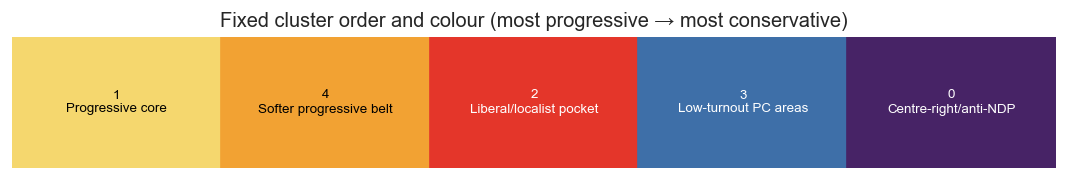

In [11]:
# ── Cluster metadata swatches, for a quick visual sanity check of the palette ─────
def _readable_text_color(hex_color):
    # Simple relative-luminance check so labels stay legible on both light and dark swatches.
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.55 else "white"

fig, ax = plt.subplots(figsize=(9, 1.6))
for pos, c in enumerate(DISPLAY_ORDER):
    color = CLUSTER_META[c]["color"]
    ax.add_patch(mpatches.Rectangle((pos, 0), 1, 1, color=color))
    ax.text(pos + 0.5, 0.5, f"{c}\n{CLUSTER_META[c]['short_label']}", ha="center", va="center",
            fontsize=8, color=_readable_text_color(color))
ax.set_xlim(0, K_CHOSEN); ax.set_ylim(0, 1)
ax.set_title("Fixed cluster order and colour (most progressive → most conservative)")
ax.axis("off")
plt.tight_layout()
plt.show()


In [12]:
# ── Build the master analysis GeoDataFrame ────────────────────────────────────────
# One row per census tract: ID, geometry, cluster ID/label, riding assignments, raw vote
# shares, city-relative deviations, within-riding deviations, and turnout. Demographic
# columns are appended once the census join is built in §6.
tracts = raw_gdf[["ct_id", "geometry"] + ALL_COLS].copy()
tracts["cluster_8f"]    = labels_8f
tracts["cluster_label"] = tracts["cluster_8f"].map(CLUSTER_LABELS)
tracts["cluster_order"] = tracts["cluster_8f"].map(lambda c: CLUSTER_META[c]["order"])
tracts = tracts.merge(riding_df, on="ct_id", how="left")

rel_named = rel_df.add_suffix("_vs_city").reset_index()
vw_named  = vw_resid_df.add_suffix("_vs_riding").reset_index()
tracts = tracts.merge(rel_named, on="ct_id", how="left").merge(vw_named, on="ct_id", how="left")

# area_km2 is used repeatedly from here on (density in §3's population table, §7's demographic
# density, §8's density scatterplot) — computed once, directly from tract geometry.
tracts["area_km2"] = tracts.to_crs(3347).geometry.area / 1e6

print(f"Master analysis table: {tracts.shape[0]} tracts x {tracts.shape[1]} columns")
print(f"CRS: {tracts.crs}  |  geometry type(s): {tracts.geom_type.unique().tolist()}")
tracts.head(3)


Master analysis table: 585 tracts x 67 columns
CRS: EPSG:4326  |  geometry type(s): ['MultiPolygon', 'Polygon']


,ct_id,geometry,mun_turnout,mun_chow,mun_bailao,mun_saunders,mun_furey,mun_matlow,mun_other,prov_turnout,...,prov_liberal_vs_riding,prov_green_vs_riding,prov_other_vs_riding,fed_turnout_vs_riding,fed_liberal_vs_riding,fed_conservative_vs_riding,fed_ndp_vs_riding,fed_green_vs_riding,fed_other_vs_riding,area_km2
0,5350001.00,"MULTIPOLYGON (((-79.30389 43.66419, -79.30397 ...",0.483020,0.516267,0.243748,0.044643,0.031523,0.054865,0.108955,0.511997,...,0.044545,-0.005595,0.004005,0.205328,0.029923,-0.002372,-0.028962,0.000857,0.000555,7.216266
1,5350002.00,"MULTIPOLYGON (((-79.38662 43.61423, -79.38693 ...",0.602303,0.776824,0.094538,0.017861,0.021045,0.051247,0.038486,0.573935,...,-0.239209,0.019264,-0.000818,0.272546,-0.070437,-0.171688,0.240019,0.002227,-0.000121,3.564345
2,5350003.00,"MULTIPOLYGON (((-79.47039 43.63188, -79.46735 ...",0.394152,0.463646,0.286530,0.055260,0.052251,0.035852,0.106460,0.483344,...,-0.007031,0.003855,0.000626,-0.275926,-0.064047,0.132029,-0.070625,0.002864,-0.000222,1.005507


## 3. Electoral Profile of Each Cluster

Now that we trust the cluster assignment and have fixed its display order and colours, we
characterise what each of the five groups actually voted for.

We start with one summary table combining cluster size, population, and a short political
signature — this is the "quick reference" row you'd reach for first when writing about any one
cluster. Getting population into this table requires the tract-level census file, so we load
just its population column here (the full census join with every demographic variable happens
in §6; re-using the same file there, not re-downloading or duplicating logic).


In [13]:
# ── Quick load: tract population, just for the summary table below ───────────────
# (§6 loads this same file again and extracts the full demographic variable set; we only need
# one column here.)
census_ct_long = pd.read_csv(CENSUS_CT_CSV)
_pop_wide = census_ct_long[census_ct_long["CHARACTERISTIC_CODE"] == "pop_2021"].set_index("GEO_NAME")["C1_COUNT_TOTAL"]
_pop_wide.index = _pop_wide.index.map(lambda x: f"{x:.2f}")   # match tracts["ct_id"] formatting

tracts["population"] = tracts["ct_id"].map(_pop_wide)
n_unmatched_pop = tracts["population"].isna().sum()
print(f"Tracts matched to a population figure: {len(tracts) - n_unmatched_pop} of {len(tracts)}")


Tracts matched to a population figure: 585 of 585


In [14]:
# ── Main cluster profile table (population + short political signature) ─────────
def short_political_signature(c):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    over, under = row.idxmax(), row.idxmin()
    turn_word = "high" if turn > 3 else ("low" if turn < -3 else "average")
    return f"{over} {row[over]:+.0f}pp / {under} {row[under]:+.0f}pp, {turn_word} turnout"

total_population = tracts["population"].sum()
profile_rows = []
for c in DISPLAY_ORDER:
    mask = tracts["cluster_8f"] == c
    profile_rows.append({
        "cluster_id": c,
        "order": CLUSTER_META[c]["order"],
        "label": CLUSTER_META[c]["label"],
        "short_label": CLUSTER_META[c]["short_label"],
        "n_tracts": int(mask.sum()),
        "pct_of_tracts": 100 * mask.mean(),
        "population": tracts.loc[mask, "population"].sum(),
        "pct_of_toronto_population": 100 * tracts.loc[mask, "population"].sum() / total_population,
        "political_signature": short_political_signature(c),
    })
main_profile_table = pd.DataFrame(profile_rows).set_index("cluster_id")
main_profile_table


,order,label,short_label,n_tracts,pct_of_tracts,population,pct_of_toronto_population,political_signature
cluster_id,,,,,,,,
1,0,Progressive Chow–NDP core,Progressive core,92,15.726496,375280.0,13.429928,"prov_ndp +30pp / prov_pc -19pp, high turnout"
4,1,Softer progressive / NDP-leaning belt,Softer progressive belt,94,16.068376,494740.0,17.704974,"prov_ndp +16pp / prov_pc -10pp, average turnout"
2,2,High-turnout Liberal/localist pocket,Liberal/localist pocket,62,10.598291,298383.0,10.678060,"prov_liberal +12pp / prov_ndp -8pp, high turnout"
3,3,Low-turnout PC-leaning areas,Low-turnout PC areas,197,33.675214,954683.0,34.164688,"prov_pc +9pp / prov_ndp -11pp, low turnout"
0,4,Centre-right / anti-NDP areas,Centre-right/anti-NDP,140,23.931624,671270.0,24.022351,"prov_pc +13pp / prov_ndp -17pp, average turnout"


This is the table to reach for first: five groups, ranging from 62 to 197 tracts and from
roughly 10% to a third of the city's population, each with a one-line political signature.
The rest of §3 unpacks the "political signature" column in full detail. `DISPLAY_ORDER` and
`LEAN_SCORE` (computed in §2) are used directly here and in every table/chart below — we don't
recompute them.


In [15]:
# ── Cluster-level electoral summary table ─────────────────────────────────────────
rows = []
for c in range(K_CHOSEN):
    mask = tracts["cluster_8f"] == c
    row = {"cluster": c, "label": CLUSTER_LABELS[c],
           "n_tracts": int(mask.sum()), "pct_of_tracts": 100 * mask.mean()}
    for col in ALL_COLS:
        row[f"raw_{col}"] = tracts.loc[mask, col].mean() * 100
        row[f"city_rel_{col}"] = tracts.loc[mask, f"{col}_vs_city"].mean() * 100
        row[f"riding_rel_{col}"] = tracts.loc[mask, f"{col}_vs_riding"].mean() * 100
    rows.append(row)
electoral_summary = pd.DataFrame(rows).set_index("cluster")

turnout_table = electoral_summary[[f"raw_{c}" for c in TURNOUT_COLS] + [f"city_rel_{c}" for c in TURNOUT_COLS]].round(1)
turnout_table.columns = [c.replace("raw_", "").replace("_turnout", " turnout (%)") for c in [f"raw_{c}" for c in TURNOUT_COLS]] + \
                         [c.replace("city_rel_", "").replace("_turnout", " turnout, vs. city (pp)") for c in [f"city_rel_{c}" for c in TURNOUT_COLS]]
turnout_table.insert(0, "label", electoral_summary["label"])
turnout_table.insert(1, "n_tracts", electoral_summary["n_tracts"])
turnout_table.loc[DISPLAY_ORDER]


,label,n_tracts,mun turnout (%),prov turnout (%),fed turnout (%),"mun turnout, vs. city (pp)","prov turnout, vs. city (pp)","fed turnout, vs. city (pp)"
cluster,,,,,,,,
1,Progressive Chow–NDP core,92,45.0,48.5,69.2,7.8,5.9,4.2
4,Softer progressive / NDP-leaning belt,94,38.9,44.1,65.9,1.7,1.5,0.9
2,High-turnout Liberal/localist pocket,62,45.1,48.0,72.9,7.9,5.3,7.9
3,Low-turnout PC-leaning areas,197,29.8,37.0,60.3,-7.4,-5.6,-4.7
0,Centre-right / anti-NDP areas,140,38.8,43.1,64.4,1.6,0.5,-0.6


### Vote-share heatmaps: city-relative deviation vs. actual level

The first heatmap is the primary read — **deviation from the citywide average**, in
percentage points, green above / red below. The second shows the same clusters' **actual**
(raw) vote shares, which matters because two clusters can share a similar *deviation* while
sitting at very different absolute levels (e.g. a modestly-below-average NDP share in an
already-NDP-heavy city is not the same as a modestly-below-average share where the party barely
registers).

Rows in both panels run most progressive (top) to most conservative (bottom), matching
`DISPLAY_ORDER` everywhere else in this notebook.


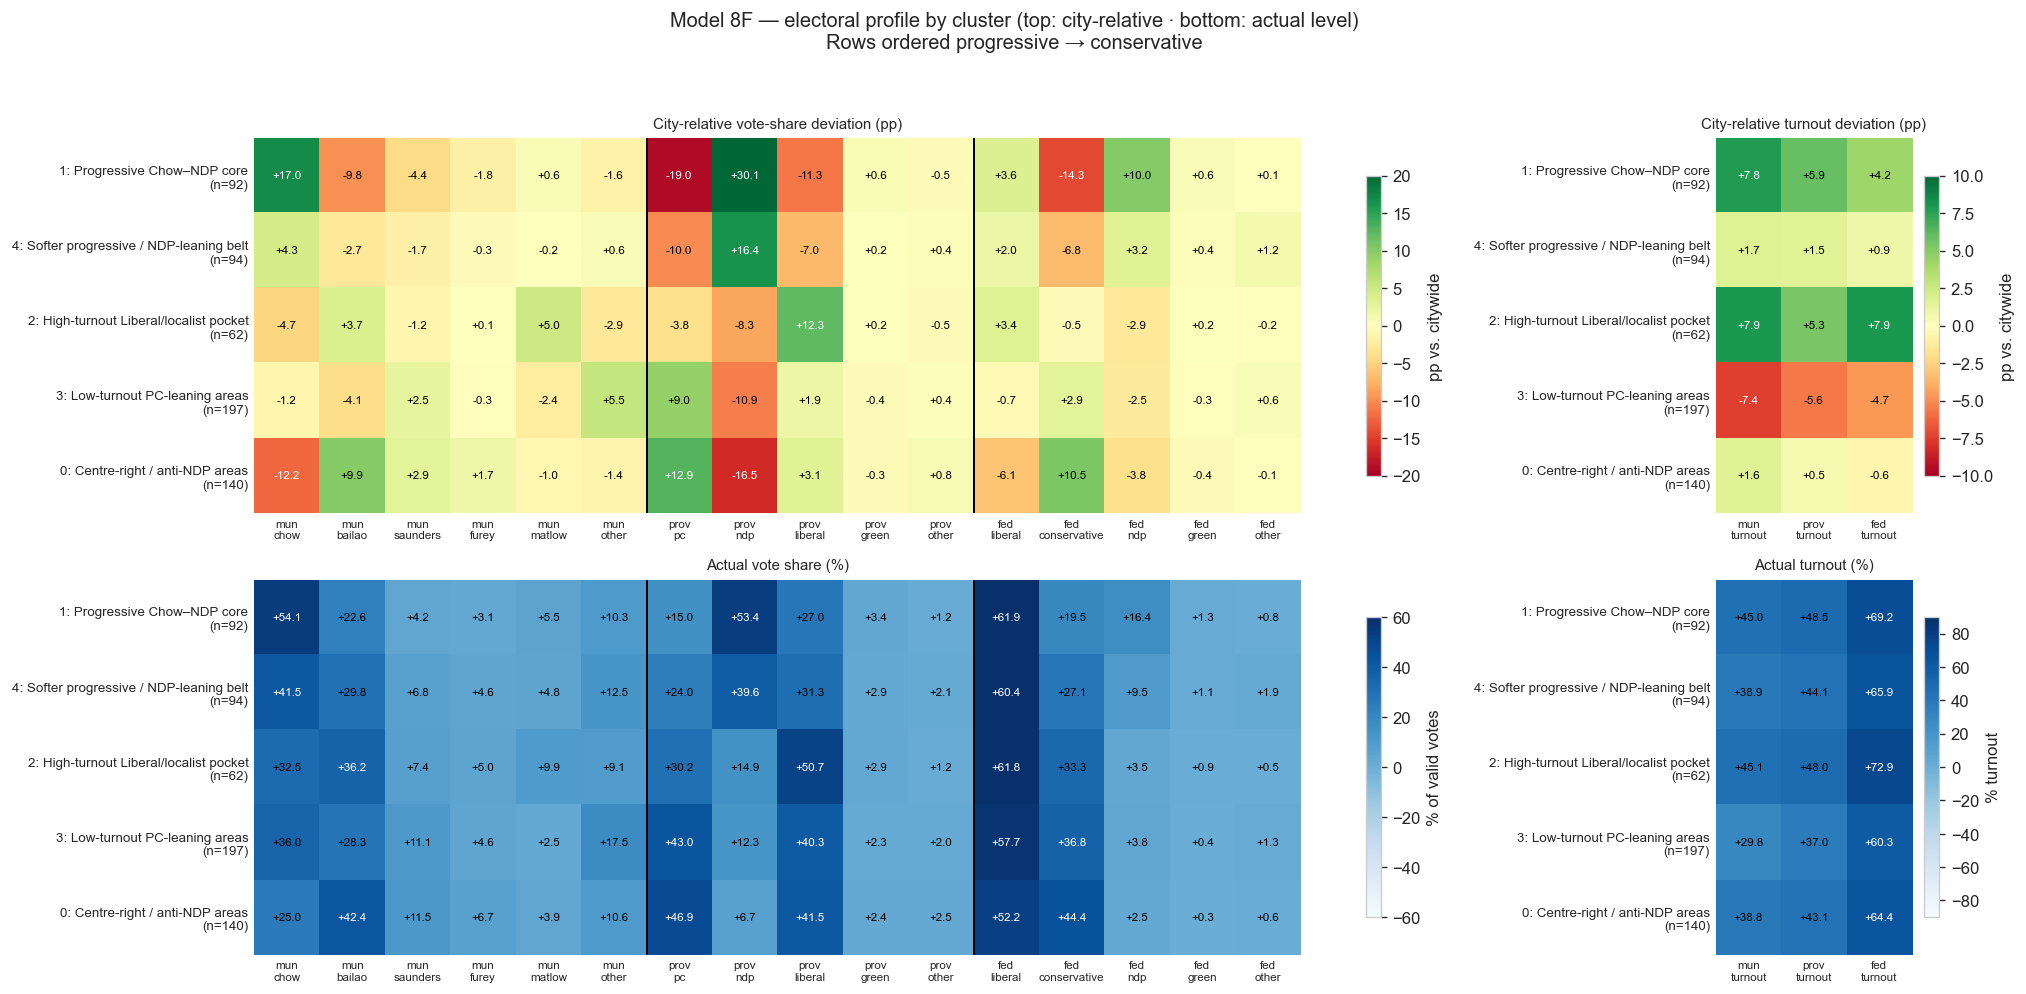

In [16]:
def draw_heatmap(ax, data, cols, title, vabs=20, cmap="RdYlGn"):
    im = ax.imshow(data[cols].values, cmap=cmap, aspect="auto", vmin=-vabs, vmax=vabs)
    for i in range(data.shape[0]):
        for j, col in enumerate(cols):
            val = data[col].iloc[i]
            txt_color = "white" if abs(val) / vabs > 0.6 else "black"
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=7, color=txt_color)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=7)
    ax.set_yticks(range(len(data))); ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(title, fontsize=9)
    # imshow heatmaps pick up the notebook-wide seaborn "whitegrid" style otherwise, which
    # draws grid lines straight through the annotated cells — turn it off explicitly here.
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return im

def cluster_row_labels(order):
    return [f"{c}: {CLUSTER_LABELS[c]}\n(n={cluster_sizes_8f[c]})" for c in order]

city_rel_profiles = check_profiles.copy()
city_rel_profiles.index = range(K_CHOSEN)

raw_profiles = electoral_summary[[f"raw_{c}" for c in ALL_COLS]].copy()
raw_profiles.columns = ALL_COLS

fig, axes = plt.subplots(2, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
plot_order = DISPLAY_ORDER
im1 = draw_heatmap(axes[0, 0], city_rel_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), SHARE_COLS,
                    "City-relative vote-share deviation (pp)", vabs=20)
im2 = draw_heatmap(axes[0, 1], city_rel_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), TURNOUT_COLS,
                    "City-relative turnout deviation (pp)", vabs=10)
im3 = draw_heatmap(axes[1, 0], raw_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), SHARE_COLS,
                    "Actual vote share (%)", vabs=60, cmap="Blues")
im4 = draw_heatmap(axes[1, 1], raw_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), TURNOUT_COLS,
                    "Actual turnout (%)", vabs=90, cmap="Blues")
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)
for ax in [axes[0, 0], axes[1, 0]]:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        ax.axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs. citywide", shrink=0.8)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs. citywide", shrink=0.8)
fig.colorbar(im3, ax=axes[1, 0], label="% of valid votes", shrink=0.8)
fig.colorbar(im4, ax=axes[1, 1], label="% turnout", shrink=0.8)
fig.suptitle("Model 8F — electoral profile by cluster (top: city-relative · bottom: actual level)\n"
             "Rows ordered progressive → conservative", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


**Reading this.** The top-left panel is the clearest single picture of what separates the five
groups electorally: the progressive core and softer progressive belt sit on the NDP/Chow side,
the Liberal/localist pocket stands out for Liberal and Matlow support rather than a left-right
position, and the low-turnout PC and centre-right/anti-NDP groups sit on the PC/Conservative/
Bailão side — with the low-turnout group's turnout deficit being the largest single number
anywhere in the top-right panel. The bottom row shows this isn't just about deviations: the
progressive core's actual NDP share (bottom-left) is genuinely high in absolute terms, not just
high relative to a low citywide baseline.


### Turnout, side by side

Turnout is one of the clearest and most consistent differentiators of the 8F solution — see
§4 below for a formal check of exactly how much it matters relative to the vote-share
variables. Here we simply look at the raw numbers, with the citywide average marked.


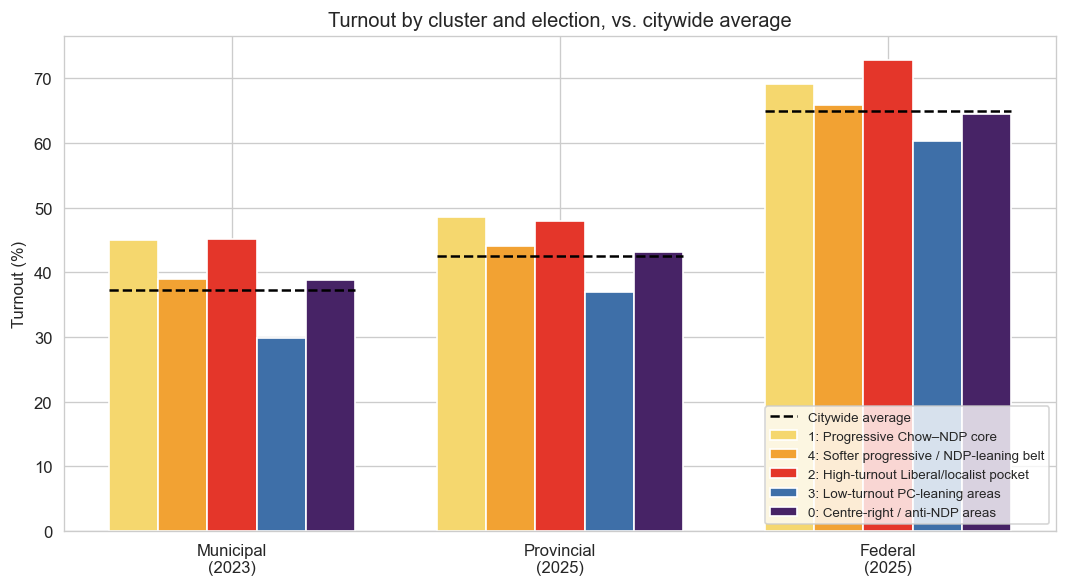

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(TURNOUT_COLS))
width = 0.15
for i, c in enumerate(DISPLAY_ORDER):
    vals = electoral_summary.loc[c, [f"raw_{t}" for t in TURNOUT_COLS]].values.astype(float)
    ax.bar(x + (i - 2) * width, vals, width, color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}")
for i, t in enumerate(TURNOUT_COLS):
    ax.hlines(citywide_s[t] * 100, x[i] - 2.5 * width, x[i] + 2.5 * width, color="black", lw=1.5, linestyle="--")
ax.plot([], [], color="black", lw=1.5, linestyle="--", label="Citywide average")
ax.set_xticks(x); ax.set_xticklabels(["Municipal\n(2023)", "Provincial\n(2025)", "Federal\n(2025)"])
ax.set_ylabel("Turnout (%)")
ax.set_title("Turnout by cluster and election, vs. citywide average")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


**Reading this.** Turnout ranks the same way in every one of the three elections: the
Liberal/localist pocket highest or near-highest, then the progressive core, then the softer
progressive belt and centre-right/anti-NDP groups near the city average, and the low-turnout PC
group clearly lowest each time. That consistency — the same ranking holding across a municipal
race, a provincial election, and a federal election with different campaigns, candidates and
turnout drivers — is itself a signal that turnout is tracking something durable about these
neighbourhoods, not one election's idiosyncrasies.


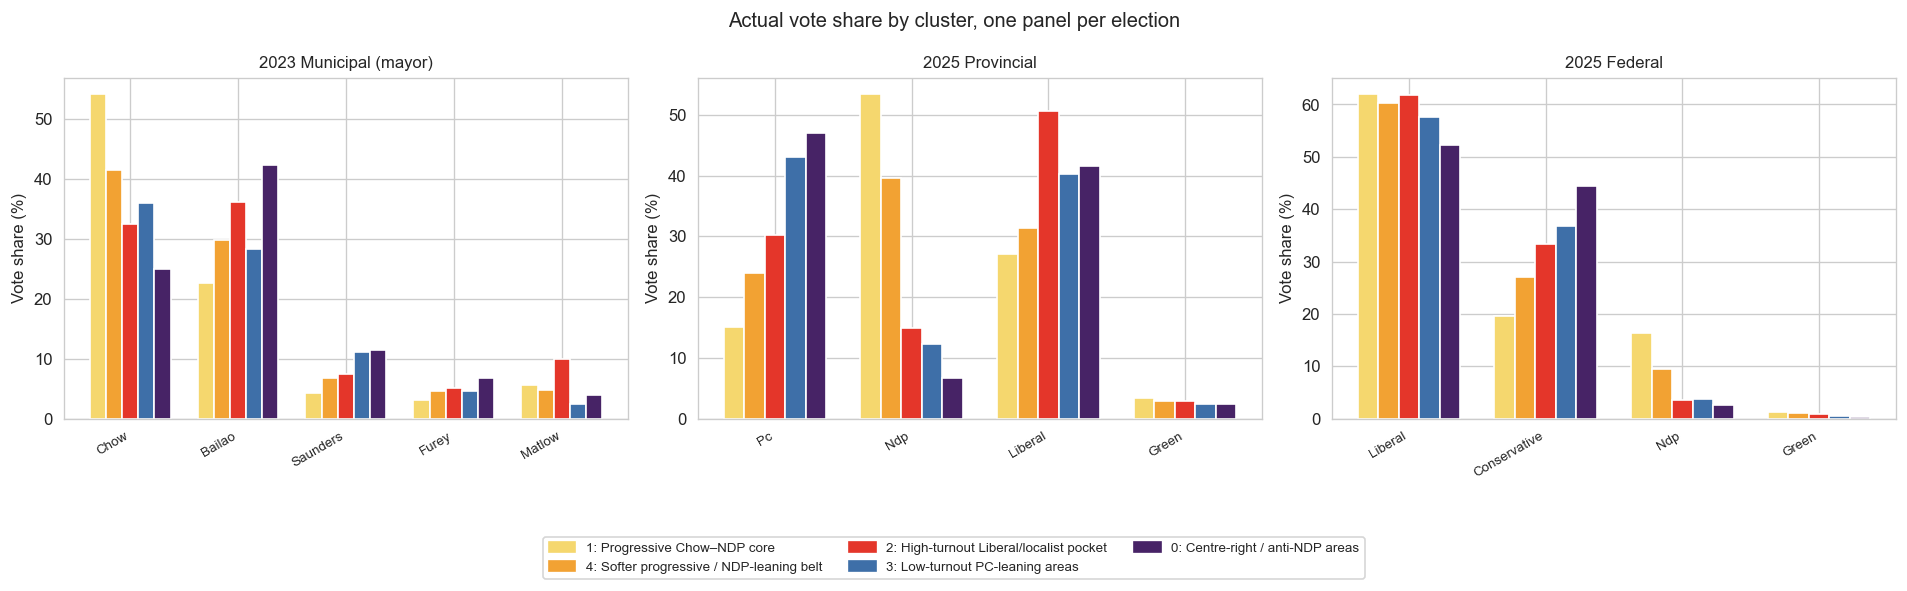

In [18]:
# ── Small multiples: vote share by party/candidate, one panel per election ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title, cols, keys) in zip(axes, [
    ("2023 Municipal (mayor)", MUN_SHARE_COLS, MUN_CANDIDATE_KEYS),
    ("2025 Provincial",        PROV_SHARE_COLS, PROV_PARTY_KEYS),
    ("2025 Federal",           FED_SHARE_COLS,  FED_PARTY_KEYS),
]):
    plot_cols = [c for c in cols if not c.endswith("_other")]
    x = np.arange(len(plot_cols))
    width = 0.15
    for i, c in enumerate(DISPLAY_ORDER):
        vals = electoral_summary.loc[c, [f"raw_{col}" for col in plot_cols]].values.astype(float)
        ax.bar(x + (i - 2) * width, vals, width, color=PALETTE_BY_ID[c])
    ax.set_xticks(x); ax.set_xticklabels([c.split("_", 1)[1].capitalize() for c in plot_cols], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Vote share (%)"); ax.set_title(title, fontsize=10)
handles = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}") for c in DISPLAY_ORDER]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=8)
fig.suptitle("Actual vote share by cluster, one panel per election", fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


**Reading this.** The municipal panel makes the Liberal/localist pocket's identity obvious at a
glance — it is the only group where Matlow clearly outpolls Saunders, and it holds a real Chow
share too, consistent with a "localist" pattern rather than a simple left-right one. The
provincial and federal panels line up more conventionally: the progressive core and softer
progressive belt lead on NDP, the low-turnout PC and centre-right/anti-NDP groups lead on
PC/Conservative, and the Liberal/localist pocket is again the outlier — this time on the
Liberal column in both the provincial and federal panels.


In [19]:
# ── Table: top over/under-performing party or candidate per cluster (city-relative) ──
top_rows = []
for c in DISPLAY_ORDER:
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    top_rows.append({
        "cluster": c, "label": CLUSTER_LABELS[c],
        "top_overperformance": f"{row.idxmax()} ({row.max():+.1f}pp)",
        "2nd_overperformance": f"{row.nlargest(2).index[1]} ({row.nlargest(2).iloc[1]:+.1f}pp)",
        "top_underperformance": f"{row.idxmin()} ({row.min():+.1f}pp)",
        "2nd_underperformance": f"{row.nsmallest(2).index[1]} ({row.nsmallest(2).iloc[1]:+.1f}pp)",
    })
pd.DataFrame(top_rows).set_index("cluster")


,label,top_overperformance,2nd_overperformance,top_underperformance,2nd_underperformance
cluster,,,,,
1,Progressive Chow–NDP core,prov_ndp (+30.1pp),mun_chow (+17.0pp),prov_pc (-19.0pp),fed_conservative (-14.3pp)
4,Softer progressive / NDP-leaning belt,prov_ndp (+16.4pp),mun_chow (+4.3pp),prov_pc (-10.0pp),prov_liberal (-7.0pp)
2,High-turnout Liberal/localist pocket,prov_liberal (+12.3pp),mun_matlow (+5.0pp),prov_ndp (-8.3pp),mun_chow (-4.7pp)
3,Low-turnout PC-leaning areas,prov_pc (+9.0pp),mun_other (+5.5pp),prov_ndp (-10.9pp),mun_bailao (-4.1pp)
0,Centre-right / anti-NDP areas,prov_pc (+12.9pp),fed_conservative (+10.5pp),prov_ndp (-16.5pp),mun_chow (-12.2pp)


### Actual vote levels, in plain numbers

Deviations are the right tool for finding what separates the clusters, but an article also
needs to be able to say "Cluster X actually got Y% of the vote." This table reports the raw,
actual average vote share and turnout for the headline candidates/parties in each cluster —
no citywide or riding adjustment — ordered progressive to conservative.


In [20]:
VOTE_LEVEL_COLS = {
    "mun_turnout": "2023 mayoral turnout (%)", "mun_chow": "Chow (%)", "mun_bailao": "Bailão (%)",
    "mun_matlow": "Matlow (%)", "mun_saunders": "Saunders (%)", "mun_other": "Municipal other (%)",
    "prov_turnout": "2025 provincial turnout (%)", "prov_pc": "PC (%)", "prov_ndp": "NDP, prov. (%)", "prov_liberal": "Liberal, prov. (%)",
    "fed_turnout": "2025 federal turnout (%)", "fed_liberal": "Liberal, fed. (%)", "fed_conservative": "Conservative, fed. (%)", "fed_ndp": "NDP, fed. (%)",
}
vote_level_table = electoral_summary[[f"raw_{c}" for c in VOTE_LEVEL_COLS]].round(1)
vote_level_table.columns = list(VOTE_LEVEL_COLS.values())
vote_level_table.insert(0, "label", electoral_summary["label"])
vote_level_table = vote_level_table.loc[DISPLAY_ORDER]
vote_level_table


,label,2023 mayoral turnout (%),Chow (%),Bailão (%),Matlow (%),Saunders (%),Municipal other (%),2025 provincial turnout (%),PC (%),"NDP, prov. (%)","Liberal, prov. (%)",2025 federal turnout (%),"Liberal, fed. (%)","Conservative, fed. (%)","NDP, fed. (%)"
cluster,,,,,,,,,,,,,,,
1,Progressive Chow–NDP core,45.0,54.1,22.6,5.5,4.2,10.3,48.5,15.0,53.4,27.0,69.2,61.9,19.5,16.4
4,Softer progressive / NDP-leaning belt,38.9,41.5,29.8,4.8,6.8,12.5,44.1,24.0,39.6,31.3,65.9,60.4,27.1,9.5
2,High-turnout Liberal/localist pocket,45.1,32.5,36.2,9.9,7.4,9.1,48.0,30.2,14.9,50.7,72.9,61.8,33.3,3.5
3,Low-turnout PC-leaning areas,29.8,36.0,28.3,2.5,11.1,17.5,37.0,43.0,12.3,40.3,60.3,57.7,36.8,3.8
0,Centre-right / anti-NDP areas,38.8,25.0,42.4,3.9,11.5,10.6,43.1,46.9,6.7,41.5,64.4,52.2,44.4,2.5


In [21]:
# ── Plain-language summary of the table above, generated from the actual numbers ──
def cluster_line(c):
    # Deliberately not .lower()'d: several short_labels contain acronyms (NDP, PC) that
    # would be mangled by naive lowercasing (e.g. "anti-NDP" -> "anti-ndp").
    return f"the {CLUSTER_META[c]['short_label']} (Cluster {c})"

highest_chow   = electoral_summary["raw_mun_chow"].idxmax()
highest_pc     = electoral_summary["raw_prov_pc"].idxmax()
highest_con    = electoral_summary["raw_fed_conservative"].idxmax()
highest_lib_p  = electoral_summary["raw_prov_liberal"].idxmax()
lowest_turnout = electoral_summary[[f"raw_{t}" for t in TURNOUT_COLS]].mean(axis=1).idxmin()

summary_md = f'''
- **Highest Chow share:** {cluster_line(highest_chow)}, at {electoral_summary.loc[highest_chow, "raw_mun_chow"]:.0f}% of the 2023 mayoral vote.
- **Highest provincial PC share:** {cluster_line(highest_pc)}, at {electoral_summary.loc[highest_pc, "raw_prov_pc"]:.0f}%.
- **Highest federal Conservative share:** {cluster_line(highest_con)}, at {electoral_summary.loc[highest_con, "raw_fed_conservative"]:.0f}%.
- **Highest provincial Liberal share:** {cluster_line(highest_lib_p)}, at {electoral_summary.loc[highest_lib_p, "raw_prov_liberal"]:.0f}% — this is the clearest single-number signature of the Liberal/localist pocket.
- **Lowest turnout, averaged across the three elections:** {cluster_line(lowest_turnout)}, at {electoral_summary.loc[lowest_turnout, [f"raw_{t}" for t in TURNOUT_COLS]].mean():.0f}% average turnout.

These are descriptions of where each number happens to be highest or lowest among the five
groups — not a claim about why, and not a statement about how any individual voted.
'''
display(Markdown(summary_md))



- **Highest Chow share:** the Progressive core (Cluster 1), at 54% of the 2023 mayoral vote.
- **Highest provincial PC share:** the Centre-right/anti-NDP (Cluster 0), at 47%.
- **Highest federal Conservative share:** the Centre-right/anti-NDP (Cluster 0), at 44%.
- **Highest provincial Liberal share:** the Liberal/localist pocket (Cluster 2), at 51% — this is the clearest single-number signature of the Liberal/localist pocket.
- **Lowest turnout, averaged across the three elections:** the Low-turnout PC areas (Cluster 3), at 42% average turnout.

These are descriptions of where each number happens to be highest or lowest among the five
groups — not a claim about why, and not a statement about how any individual voted.


## 4. What Splits the City?

The profile heatmap already suggests answers, but we can be more systematic: for each of the
18 underlying features (turnout + vote share x 3 elections), how much of its variance across
all 585 tracts is *between* the five clusters, versus *within* them? A feature with a high
between/total ratio is one the clustering leans on heavily to tell groups apart; a feature with
a low ratio varies just as much within clusters as between them, and isn't doing much
differentiating work.

This is a description of the fitted clustering solution, not a causal or predictive claim.


In [22]:
def between_within_variance(df_vals, labels, k):
    # Between-cluster variance share for each column: SS_between / SS_total.
    grand_mean = df_vals.mean(axis=0)
    ss_total = ((df_vals - grand_mean) ** 2).sum(axis=0)
    ss_between = np.zeros(df_vals.shape[1])
    for c in range(k):
        mask = labels == c
        if mask.sum() == 0:
            continue
        cluster_mean = df_vals[mask].mean(axis=0)
        ss_between += mask.sum() * (cluster_mean - grand_mean) ** 2
    return np.divide(ss_between, ss_total, out=np.zeros_like(ss_total), where=ss_total > 0)

# Diagnostics run on the same block-weighted, blended feature space the k-means actually saw,
# so "most differentiating" reflects what the model used, not the raw unweighted vote shares.
bw_ratio = between_within_variance(X_blend_8f, labels_8f, K_CHOSEN)
blended_col_names = [f"{c}_city" for c in ALL_COLS] + [f"{c}_riding" for c in ALL_COLS]
diff_table = pd.DataFrame({"feature": blended_col_names, "between_var_share": bw_ratio}) \
    .sort_values("between_var_share", ascending=False).reset_index(drop=True)

# Same diagnostic on the raw (unweighted) city-relative shares, for an interpretable pp range.
raw_range = pd.Series(
    {col: check_profiles[col].max() - check_profiles[col].min() for col in ALL_COLS},
    name="max_minus_min_pp",
)

print("Top 10 most differentiating features (share of variance that is between-cluster):")
diff_table.head(10)


Top 10 most differentiating features (share of variance that is between-cluster):


,feature,between_var_share
0,prov_ndp_city,0.748699
1,prov_pc_city,0.700913
2,fed_ndp_city,0.673520
3,fed_conservative_city,0.665870
4,mun_chow_city,0.657300
5,mun_saunders_city,0.657118
6,mun_bailao_city,0.515418
7,prov_turnout_city,0.456137
8,mun_furey_city,0.425456
9,fed_green_city,0.420744


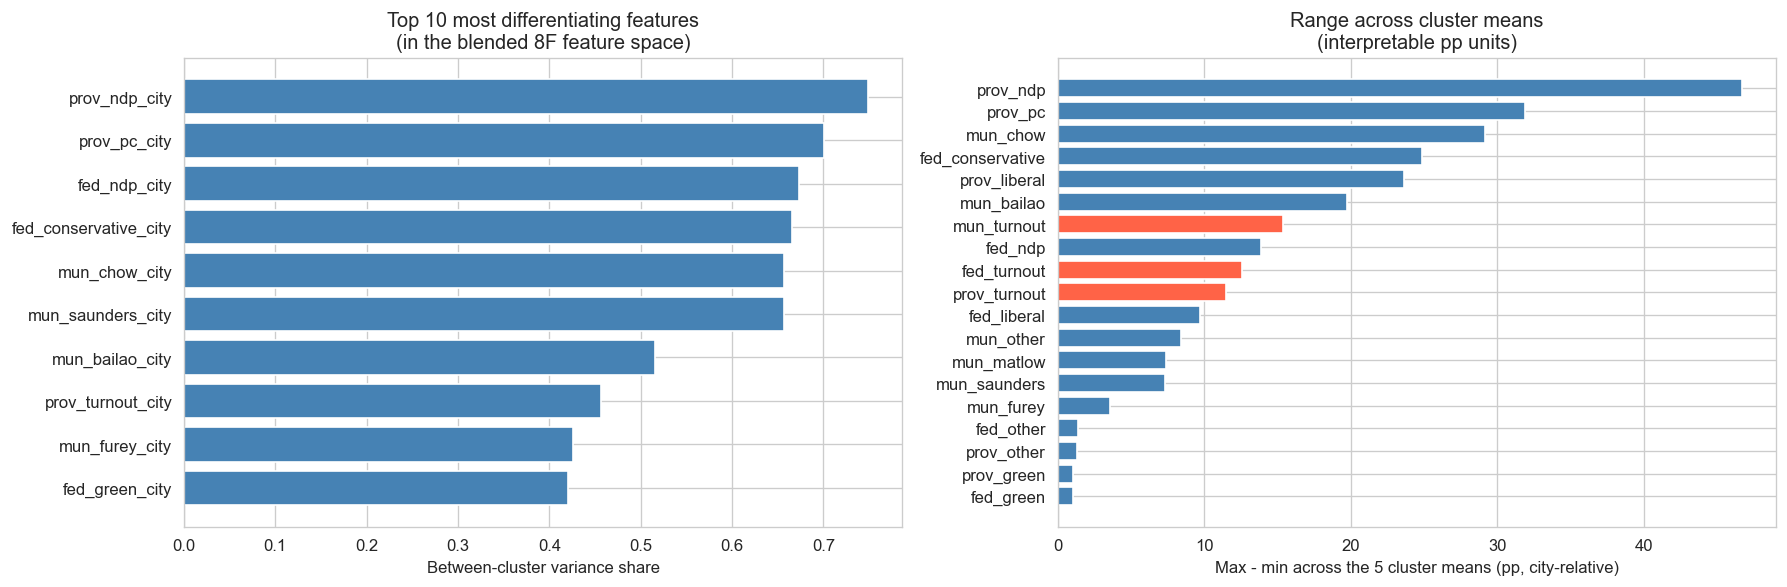

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10 = diff_table.head(10)
axes[0].barh(top10["feature"][::-1], top10["between_var_share"][::-1], color="steelblue")
axes[0].set_xlabel("Between-cluster variance share")
axes[0].set_title("Top 10 most differentiating features\n(in the blended 8F feature space)")

range_sorted = raw_range.sort_values(ascending=False)
colors = ["tomato" if "turnout" in c else "steelblue" for c in range_sorted.index]
axes[1].barh(range_sorted.index[::-1], range_sorted.values[::-1], color=colors[::-1])
axes[1].set_xlabel("Max - min across the 5 cluster means (pp, city-relative)")
axes[1].set_title("Range across cluster means\n(interpretable pp units)")
plt.tight_layout()
plt.show()


**Reading this.** Provincial NDP and PC vote share dominate the "most differentiating" list on
both measures — consistent with §3, where the sharpest cross-cluster contrasts were on those
two columns. Turnout variables (tomato bars, right panel) show up mid-table rather than at the
very top: they matter — the low-turnout PC group's deficit and the Liberal/localist pocket's
surplus are both real and consistent — but the single biggest range-in-pp terms belongs to
partisan vote share, not turnout. In other words: **the 8F clusters are primarily a
partisan-lean split with a turnout dimension layered on top, not a turnout-first split with
partisanship as a footnote.**


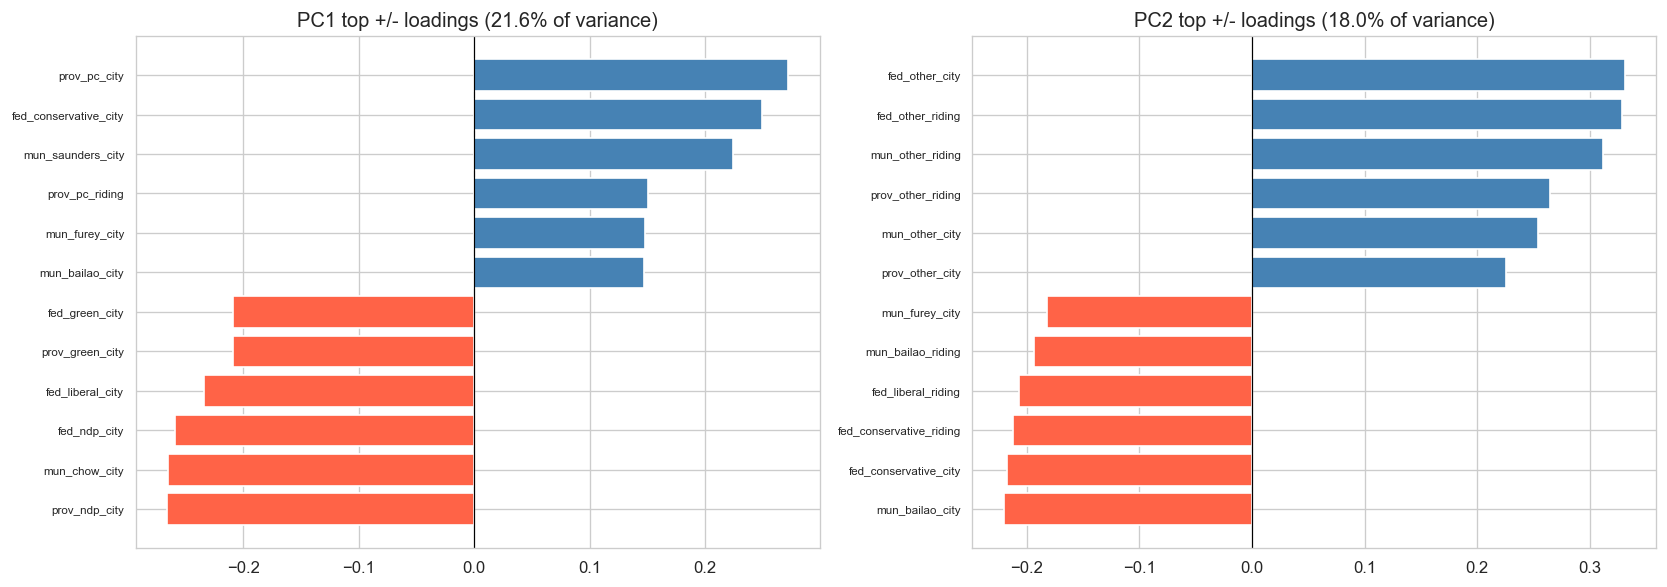

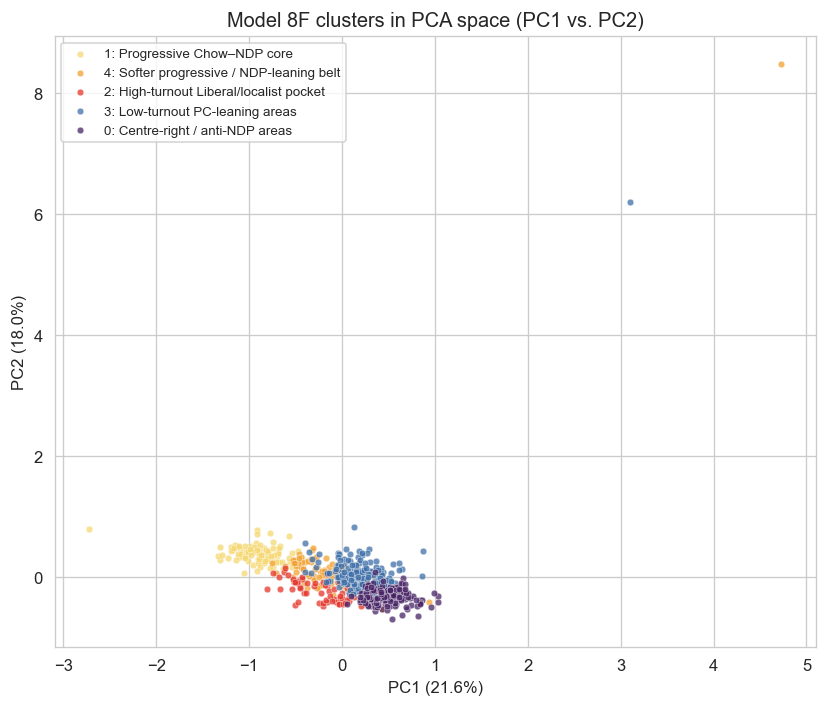

In [24]:
# ── PCA loadings and scatter for the blended 8F feature space ────────────────────
pca_8f = PCA(n_components=min(6, X_blend_8f.shape[1]), random_state=RANDOM_STATE).fit(X_blend_8f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pc_idx, ax in enumerate(axes):
    loadings = pd.Series(pca_8f.components_[pc_idx], index=blended_col_names).sort_values()
    top_loadings = pd.concat([loadings.head(6), loadings.tail(6)])
    colors = ["tomato" if v < 0 else "steelblue" for v in top_loadings]
    ax.barh(range(len(top_loadings)), top_loadings.values, color=colors)
    ax.set_yticks(range(len(top_loadings))); ax.set_yticklabels(top_loadings.index, fontsize=7)
    ax.axvline(0, color="black", lw=0.7)
    ax.set_title(f"PC{pc_idx + 1} top +/- loadings ({pca_8f.explained_variance_ratio_[pc_idx] * 100:.1f}% of variance)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
X_pca_plot = pca_8f.transform(X_blend_8f)
for c in DISPLAY_ORDER:
    mask = labels_8f == c
    ax.scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 1], color=PALETTE_BY_ID[c], s=16, alpha=0.75,
               edgecolors="white", linewidths=0.3, label=f"{c}: {CLUSTER_LABELS[c]}")
ax.set_xlabel(f"PC1 ({pca_8f.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_8f.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("Model 8F clusters in PCA space (PC1 vs. PC2)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading this.** PC1 is essentially the NDP/Chow ↔ PC/Bailão axis (dominated by
`prov_ndp_city`, `prov_pc_city`, `mun_chow_city`, `mun_bailao_city`) — the same axis that
separates the progressive-leaning clusters from the PC/conservative-leaning clusters in every
chart so far. PC2 leans on the within-riding block (`_riding` suffix) more than PC1 does, which
is the axis that isolates the Liberal/localist pocket: it is defined less by *how far left or
right* a tract sits than by *how much it diverges from its own riding*, which is exactly what
the Matlow/Liberal localist story implies. The scatter shows that cluster sitting apart along
that second dimension rather than simply between the progressive and conservative clusters on
PC1 — visual confirmation that it is a genuinely distinct group, not a moderate middle ground.


In [25]:
# ── Cluster centroid distances in PCA space ───────────────────────────────────────
centroids_pca = np.array([X_pca_8f[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)])
dist_matrix = pd.DataFrame(
    np.linalg.norm(centroids_pca[:, None, :] - centroids_pca[None, :, :], axis=-1),
    index=[f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)],
    columns=[f"{c}" for c in range(K_CHOSEN)],
).loc[[f"{c}: {CLUSTER_LABELS[c]}" for c in DISPLAY_ORDER], [str(c) for c in DISPLAY_ORDER]]
print("Pairwise centroid distances in PCA space (larger = more distinct; rows/cols ordered progressive -> conservative):")
dist_matrix.round(2)


Pairwise centroid distances in PCA space (larger = more distinct; rows/cols ordered progressive -> conservative):


,1,4,2,3,0
1: Progressive Chow–NDP core,0.00,1.01,1.19,1.30,1.59
4: Softer progressive / NDP-leaning belt,1.01,0.00,0.94,0.91,0.96
2: High-turnout Liberal/localist pocket,1.19,0.94,0.00,0.99,0.99
3: Low-turnout PC-leaning areas,1.30,0.91,0.99,0.00,0.80
0: Centre-right / anti-NDP areas,1.59,0.96,0.99,0.80,0.00


**On the two questions this diagnostic was meant to answer:**

- **Is the Liberal/localist pocket really distinct, or a moderate middle ground?** The
  centroid-distance table above shows it is *not* closest to some midpoint between the
  progressive and conservative clusters — it sits at a comparable or larger distance from
  every other cluster than they sit from each other, which is what we'd expect from a group
  defined by a different axis (riding-local deviation) rather than a weaker version of the
  main left–right split.
- **Is the low-turnout PC cluster really distinct from the centre-right/anti-NDP cluster?**
  They are the two *closest* centroids in the table — the smallest distance in the whole
  matrix. They agree on direction (both lean PC/anti-NDP) and are separated mainly by how far
  below the citywide turnout average they sit. That's a real, consistent distinction (§3's
  turnout chart shows it holding across all three elections) but it's the softest of the five
  boundaries in this model — worth flagging plainly in any write-up rather than presenting all
  five groups as equally sharply separated.


## 5. Spatial Concentration and Geography

Where does each group actually live? We start with the plain cluster map, then the same map
with **ward boundaries** overlaid (using the same dissolved ward polygons `ward_gdf` built for
riding assignment in §2 — no separate ward-boundary file is needed), then look at how clusters
distribute across wards and ridings — both "what share of ward X is cluster Y" and "what share
of cluster Y sits in ward X" — since those answer different questions (is a ward internally
consistent? vs. is a cluster geographically concentrated or scattered across many ridings?).


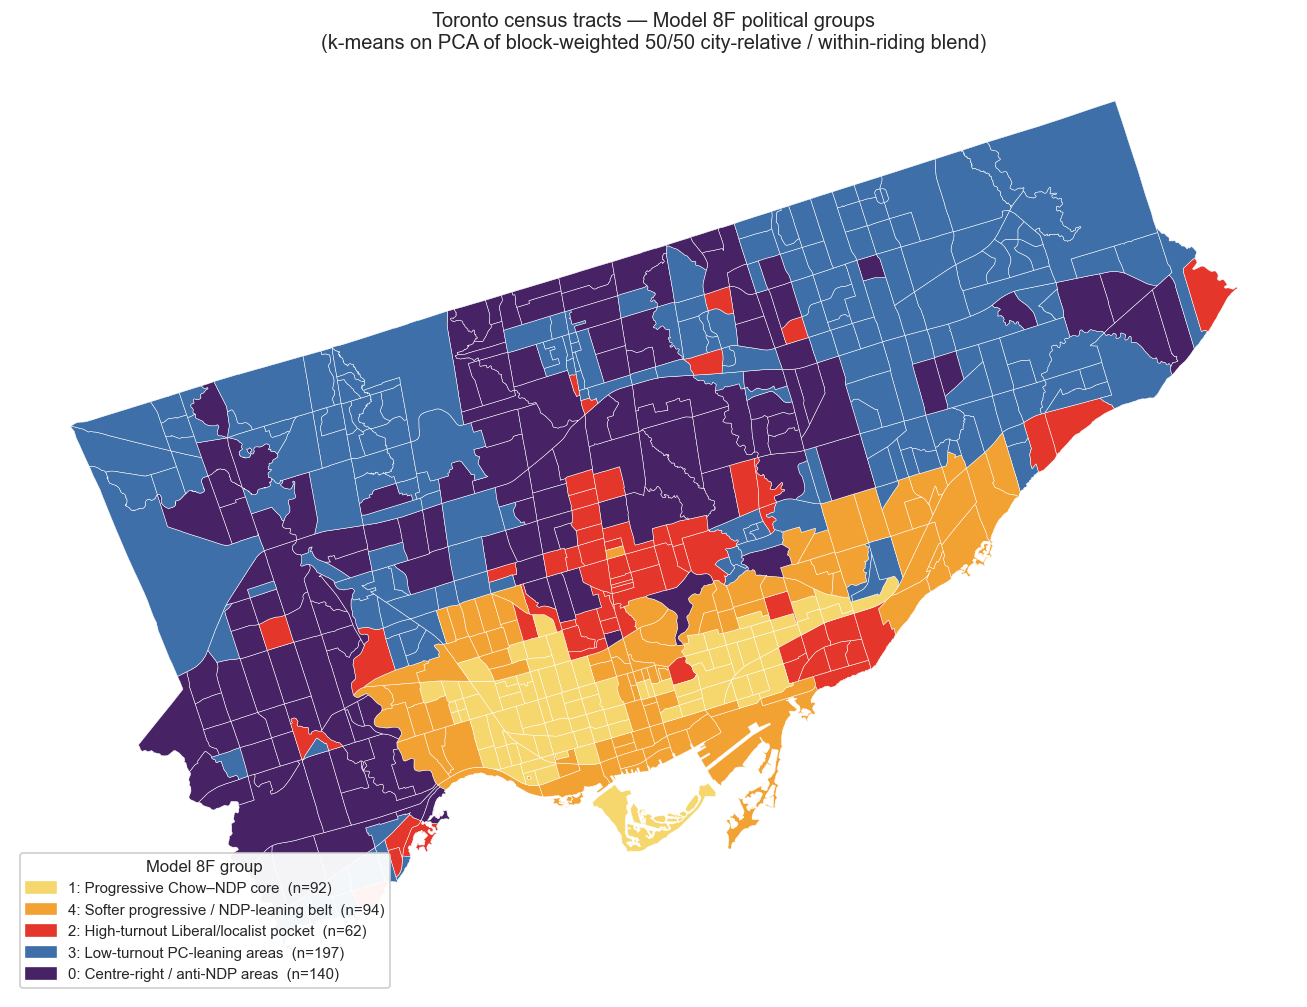

In [26]:
def plot_cluster_map(ax, show_wards=False):
    cmap_8f = mcolors.ListedColormap([PALETTE_BY_ID[c] for c in range(K_CHOSEN)])
    tracts.plot(column="cluster_8f", ax=ax, categorical=True, cmap=cmap_8f, edgecolor="white", linewidth=0.3, legend=False)
    if show_wards:
        ward_gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=1.1)
    patches = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}  (n={cluster_sizes_8f[c]})") for c in DISPLAY_ORDER]
    ax.legend(handles=patches, loc="lower left", fontsize=9, framealpha=0.95, title="Model 8F group")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 12))
plot_cluster_map(ax, show_wards=False)
ax.set_title("Toronto census tracts — Model 8F political groups\n"
             "(k-means on PCA of block-weighted 50/50 city-relative / within-riding blend)", fontsize=12)
plt.tight_layout()
plt.show()


**Reading this.** The map is not a clean "downtown left, suburbs right" picture. The
progressive core and softer progressive belt do sit where a conventional story would expect
them — the old City of Toronto, hugging the downtown core and the lake east toward the Beaches.
But the centre-right/anti-NDP group is not purely an outer-suburban story: alongside a large
block across Etobicoke, it also forms a dense, contiguous mass across a central-north swath
(roughly the former City of North York / midtown corridor) — a centre-right pattern sitting well
inside the old inner suburbs, not out at the city's edge. The low-turnout PC-leaning group is
the one that actually reads as classically suburban/exurban: it dominates the far northwest, the
far northeast (Scarborough), and fills in much of the space between the other groups. The
Liberal/localist pocket shows up as smaller patches threaded through and around the
downtown/midtown area rather than a single bloc — consistent with a locally-anchored rather
than broadly geographic identity.


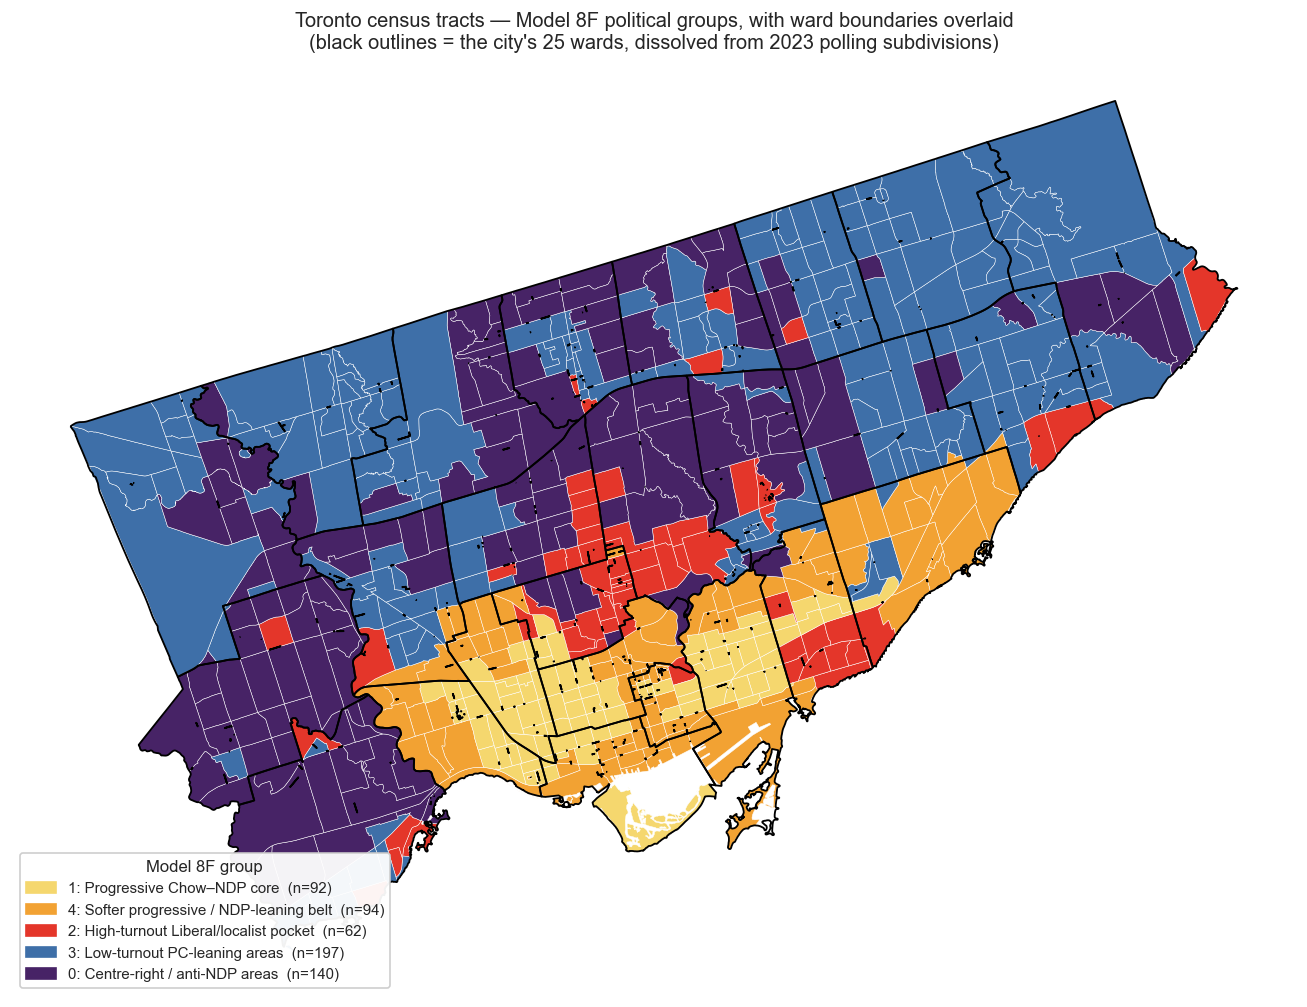

In [27]:
fig, ax = plt.subplots(figsize=(11, 12))
plot_cluster_map(ax, show_wards=True)
ax.set_title("Toronto census tracts — Model 8F political groups, with ward boundaries overlaid\n"
             "(black outlines = the city's 25 wards, dissolved from 2023 polling subdivisions)", fontsize=12)
plt.tight_layout()
plt.show()


**Reading this.** Overlaying ward boundaries makes it easy to see, at a glance, which wards a
given cluster's tracts fall inside — useful for cross-referencing against the stacked bar chart
right below, and for a reader who knows Toronto's ward map better than its census tracts. A few
wards visibly hold almost entirely one colour (e.g. the wards anchored in the progressive
core's downtown band); most others clearly mix two or three colours within their boundary — the
stacked bar chart quantifies exactly how mixed each of the 25 wards is.


In [28]:
# ── Cluster composition by ward / provincial riding / federal riding ─────────────
def geography_tables(tracts, geo_col, geo_label):
    ct = pd.crosstab(tracts[geo_col], tracts["cluster_8f"])
    ct = ct[DISPLAY_ORDER]
    ct.columns = [f"{c}: {CLUSTER_LABELS[c]}" for c in ct.columns]
    share_within_geo = ct.div(ct.sum(axis=1), axis=0) * 100      # "what % of this geography is cluster c"
    share_of_cluster = ct.div(ct.sum(axis=0), axis=1) * 100      # "what % of cluster c sits in this geography"
    return ct, share_within_geo, share_of_cluster

ward_counts, ward_share_within, ward_share_of_cluster = geography_tables(tracts, "ward_label", "ward")
prov_counts, prov_share_within, prov_share_of_cluster = geography_tables(tracts, "prov_riding", "provincial riding")
fed_counts,  fed_share_within,  fed_share_of_cluster  = geography_tables(tracts, "fed_riding",  "federal riding")

print(f"Wards: {tracts['ward_label'].nunique()}  |  Provincial ridings: {tracts['prov_riding'].nunique()}  |  "
      f"Federal ridings: {tracts['fed_riding'].nunique()}")
ward_counts


Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


,1: Progressive Chow–NDP core,4: Softer progressive / NDP-leaning belt,2: High-turnout Liberal/localist pocket,3: Low-turnout PC-leaning areas,0: Centre-right / anti-NDP areas
ward_label,,,,,
Ward 1,0,0,0,14,8
Ward 10,8,14,0,0,0
Ward 11,13,10,1,0,0
Ward 12,4,3,13,0,4
Ward 13,7,12,1,0,0
Ward 14,19,9,0,0,0
Ward 15,0,0,10,3,10
Ward 16,0,0,3,8,9
Ward 17,0,0,2,12,10


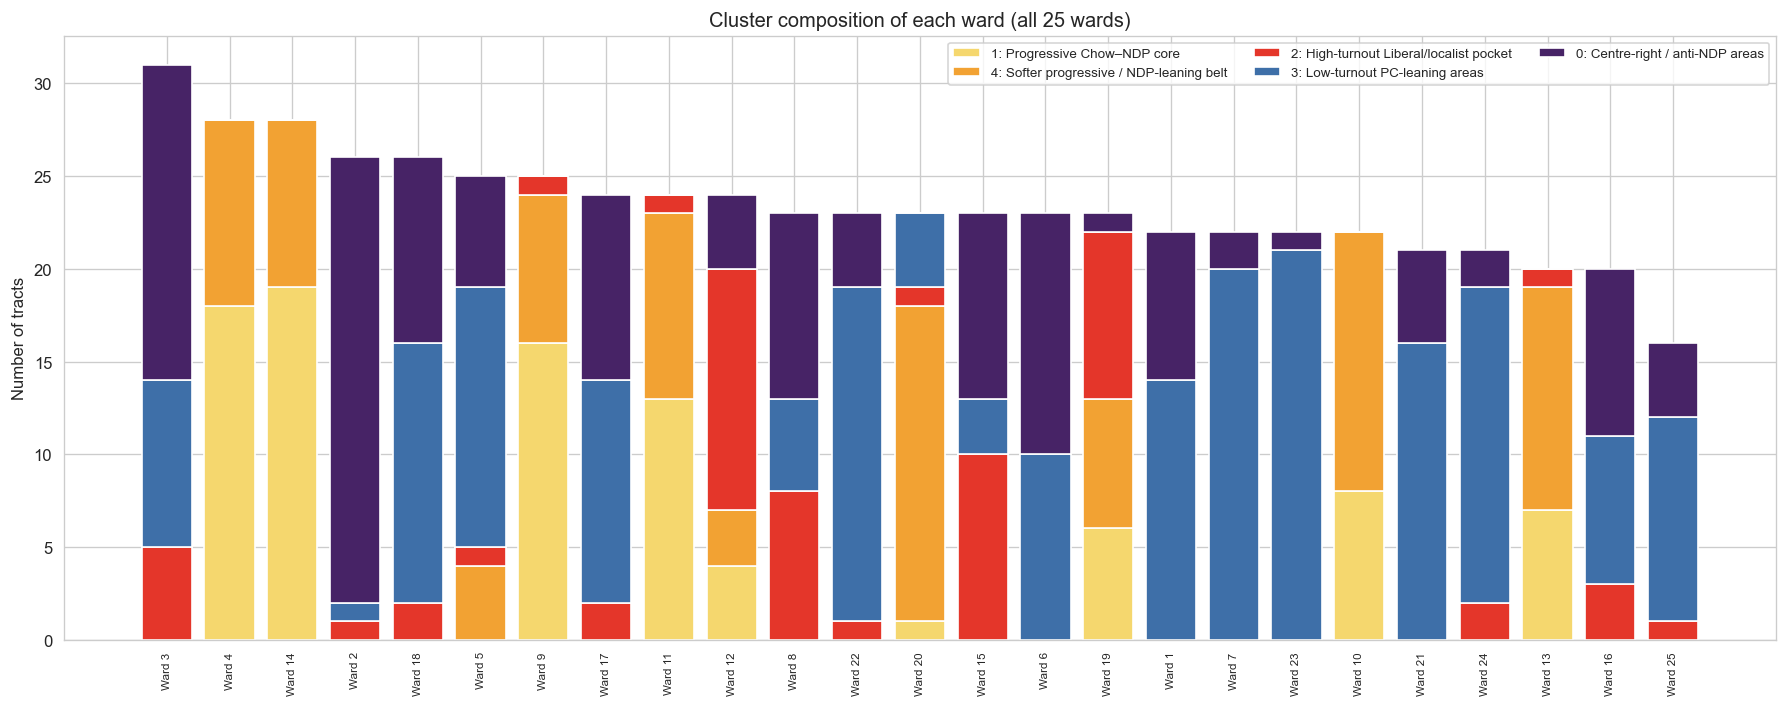

In [29]:
# ── Stacked bar: cluster composition of each ward, sorted by size ────────────────
fig, ax = plt.subplots(figsize=(15, 6))
plot_wards = ward_counts.loc[ward_counts.sum(axis=1).sort_values(ascending=False).index]
bottom = np.zeros(len(plot_wards))
for c in DISPLAY_ORDER:
    vals = plot_wards[f"{c}: {CLUSTER_LABELS[c]}"].values
    ax.bar(range(len(plot_wards)), vals, bottom=bottom, color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}")
    bottom += vals
ax.set_xticks(range(len(plot_wards))); ax.set_xticklabels(plot_wards.index, rotation=90, fontsize=7)
ax.set_ylabel("Number of tracts"); ax.set_title("Cluster composition of each ward (all 25 wards)")
ax.legend(fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()


**Reading this.** The ward chart shows both patterns at once, depending on the ward. A handful
of wards are close to single-cluster: Ward 2 is almost entirely the centre-right/anti-NDP
group, Wards 4 and 14 are almost entirely the two progressive-leaning groups, and Wards 7 and
23 are almost entirely the low-turnout PC group. But most wards in the middle of the chart are
genuine three- or four-cluster mixes, with no single group holding a majority of that ward's
tracts. So the honest read is: **the extremes of the model (the strongest progressive wards and
the most suburban, low-turnout wards) are close to riding-shaped, but the broad middle of the
city is not** — which is exactly the kind of nuance a single-race, ward-level election map
would flatten out.


In [30]:
# ── Top geographies for each cluster (by share of cluster's tracts) ──────────────
def top_geographies_table(share_of_cluster, top_n=5):
    out = {}
    for col in share_of_cluster.columns:
        top = share_of_cluster[col].sort_values(ascending=False).head(top_n)
        out[col] = [f"{geo} ({pct:.0f}%)" for geo, pct in top.items()]
    return pd.DataFrame(out).T

print("Top wards per cluster (share of that cluster's tracts found there):")
top_geographies_table(ward_share_of_cluster)


Top wards per cluster (share of that cluster's tracts found there):


,0,1,2,3,4
1: Progressive Chow–NDP core,Ward 14 (21%),Ward 4 (20%),Ward 9 (17%),Ward 11 (14%),Ward 10 (9%)
4: Softer progressive / NDP-leaning belt,Ward 20 (18%),Ward 10 (15%),Ward 13 (13%),Ward 4 (11%),Ward 11 (11%)
2: High-turnout Liberal/localist pocket,Ward 12 (21%),Ward 15 (16%),Ward 19 (15%),Ward 8 (13%),Ward 3 (8%)
3: Low-turnout PC-leaning areas,Ward 23 (11%),Ward 7 (10%),Ward 22 (9%),Ward 24 (9%),Ward 21 (8%)
0: Centre-right / anti-NDP areas,Ward 2 (17%),Ward 3 (12%),Ward 6 (9%),Ward 15 (7%),Ward 8 (7%)


In [31]:
print("Top provincial ridings per cluster:")
top_geographies_table(prov_share_of_cluster)


Top provincial ridings per cluster:


,0,1,2,3,4
1: Progressive Chow–NDP core,Toronto—Danforth (21%),Parkdale—High Park (20%),Davenport (17%),University—Rosedale (14%),Spadina—Fort York (9%)
4: Softer progressive / NDP-leaning belt,Scarborough Southwest (18%),Spadina—Fort York (15%),Toronto Centre (13%),Parkdale—High Park (11%),University—Rosedale (11%)
2: High-turnout Liberal/localist pocket,Toronto—St. Paul's (21%),Don Valley West (16%),Beaches—East York (15%),Eglinton—Lawrence (13%),Etobicoke—Lakeshore (8%)
3: Low-turnout PC-leaning areas,Scarborough North (11%),Humber River—Black Creek (10%),Scarborough—Agincourt (9%),Scarborough—Guildwood (9%),Scarborough Centre (8%)
0: Centre-right / anti-NDP areas,Etobicoke Centre (17%),Etobicoke—Lakeshore (12%),York Centre (9%),Don Valley West (7%),Eglinton—Lawrence (7%)


In [32]:
print("Top federal ridings per cluster:")
top_geographies_table(fed_share_of_cluster)


Top federal ridings per cluster:


,0,1,2,3,4
1: Progressive Chow–NDP core,Taiaiako’n—Parkdale—High Park (21%),Toronto—Danforth (21%),University—Rosedale (18%),Davenport (17%),Toronto Centre (8%)
4: Softer progressive / NDP-leaning belt,Scarborough Southwest (18%),Toronto Centre (14%),Taiaiako’n—Parkdale—High Park (13%),Davenport (12%),Spadina—Harbourfront (12%)
2: High-turnout Liberal/localist pocket,Toronto—St. Paul's (26%),Don Valley West (18%),Beaches—East York (15%),Eglinton—Lawrence (13%),Etobicoke—Lakeshore (6%)
3: Low-turnout PC-leaning areas,Scarborough North (13%),Humber River—Black Creek (10%),Scarborough—Agincourt (10%),Scarborough—Woburn (10%),Willowdale (7%)
0: Centre-right / anti-NDP areas,Etobicoke Centre (15%),Etobicoke—Lakeshore (11%),York Centre (9%),Don Valley North (8%),Scarborough Centre—Don Valley East (8%)


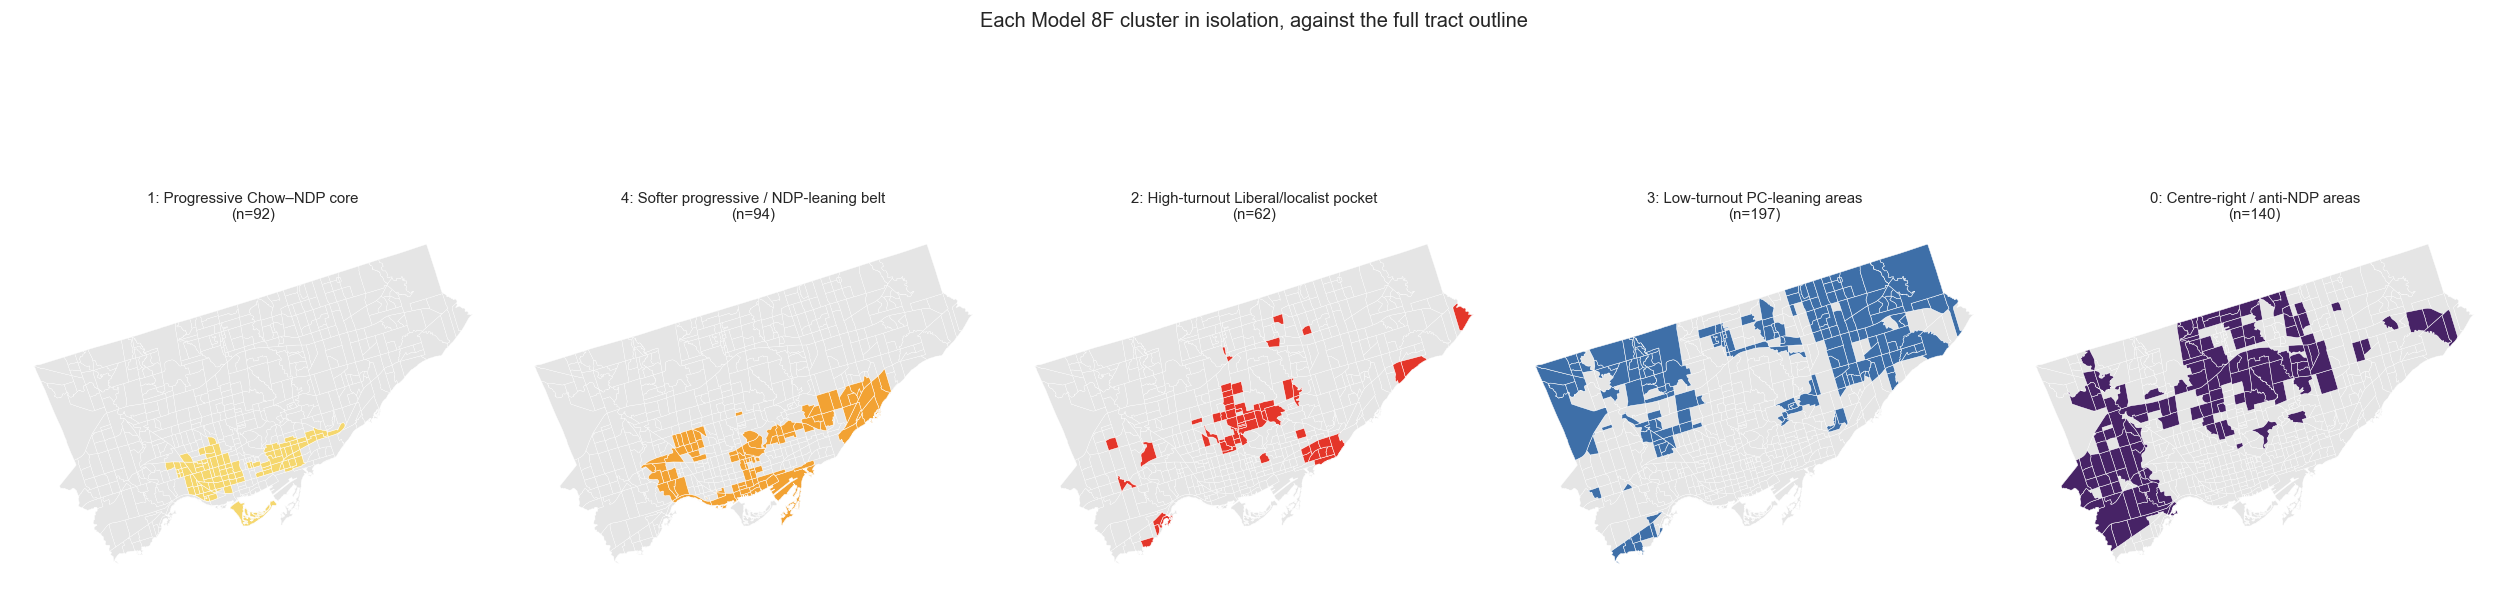

In [33]:
# ── Small maps isolating each cluster ─────────────────────────────────────────────
fig, axes = plt.subplots(1, K_CHOSEN, figsize=(4.2 * K_CHOSEN, 6))
for c, ax in zip(DISPLAY_ORDER, axes):
    tracts.plot(ax=ax, color="#e5e5e5", edgecolor="white", linewidth=0.2)
    tracts[tracts["cluster_8f"] == c].plot(ax=ax, color=PALETTE_BY_ID[c], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{c}: {CLUSTER_LABELS[c]}\n(n={cluster_sizes_8f[c]})", fontsize=9)
    ax.axis("off")
fig.suptitle("Each Model 8F cluster in isolation, against the full tract outline", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Reading this.** The five clusters differ sharply in spatial coherence:

- **The progressive core** and **softer progressive belt** are the most spatially coherent —
  each forms one compact, contiguous band along the downtown lakefront (the softer belt
  wrapping around the core to its north and east), reading as a genuine, unified "old city"
  corridor rather than scattered pockets.
- **The centre-right/anti-NDP group** is mostly one large contiguous mass spanning Etobicoke
  and a central-north swath, with a couple of smaller detached islands elsewhere — still
  reasonably coherent, but not a single unbroken shape.
- **The low-turnout PC-leaning group** is the largest group and forms several large,
  internally contiguous blobs (far northwest, far northeast/Scarborough, and a broad
  north-central swath) rather than one connected region — coherent within each of those areas,
  but split across three separate parts of the city.
- **The Liberal/localist pocket** is clearly the most fragmented of the five: a cluster of
  adjoining tracts in midtown plus several small, standalone one- or two-tract islands
  scattered near the core, in the far east tip, and in the southwest. This fits the story told
  in §3–§4: it is defined more by a specific local/candidate pattern than by a single
  contiguous political geography, so a fragmented footprint is expected rather than a modelling
  concern.


## 6. Loading and Preparing the Census CT Data

`data/clustering_neighbourhoods/census/toronto-ct-small.csv` is a **long-form** 2021 Census
file, structured exactly like the ADA file used in an earlier version of this notebook — one
row per (geography, characteristic) pair — but at the **census tract (CT)** level, the same
geography our 8F clusters are built on. `census_ct_long` was already loaded in §3 to pull the
population column into the main profile table; here we inspect it properly and extract the
full demographic variable set.

**Why this is simpler than the ADA version:** a tract nests inside exactly one ADA, but roughly
80% of ADAs span *more than one* tract, which meant the ADA version had to disaggregate ADA
totals down to tracts by land area — an explicit modelling assumption, clearly caveated, but an
assumption nonetheless. The CT file needs none of that: **each of our 585 clustered tracts has
its own directly-published census record.** No allocation, no area-weighting, no split-geography
caveat. We still verify the join carefully below rather than assuming it's clean.


In [34]:
print(f"Rows: {len(census_ct_long)}  |  Unique CTs (GEO_NAME): {census_ct_long['GEO_NAME'].nunique()}  |  "
      f"Unique characteristics: {census_ct_long['CHARACTERISTIC_ID'].nunique()}")
print(f"Duplicate (GEO_NAME, CHARACTERISTIC_ID) rows: {census_ct_long.duplicated(['GEO_NAME', 'CHARACTERISTIC_ID']).sum()}")
print(f"GEO_NAME dtype: {census_ct_long['GEO_NAME'].dtype}  |  sample values: {sorted(census_ct_long['GEO_NAME'].unique())[:5]}")
census_ct_long.head(3)


Rows: 114448  |  Unique CTs (GEO_NAME): 622  |  Unique characteristics: 184
Duplicate (GEO_NAME, CHARACTERISTIC_ID) rows: 0
GEO_NAME dtype: float64  |  sample values: [np.float64(5350001.0), np.float64(5350002.0), np.float64(5350003.0), np.float64(5350004.0), np.float64(5350005.0)]


,GEO_NAME,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE,C1_COUNT_TOTAL,C10_RATE_TOTAL
0,5350001.0,1,"Population, 2021",pop_2021,599.0,NaN
1,5350001.0,2,"Population, 2016",pop_2016,595.0,NaN
2,5350001.0,3,"Population percentage change, 2016 to 2021",pop_pct_change,0.7,0.7


In [35]:
# Confirm the specific characteristic IDs requested in the brief actually exist with the
# names/codes expected, rather than assuming the CT file matches the ADA file's structure.
requested = census_ct_long[census_ct_long["CHARACTERISTIC_ID"].isin(CENSUS_CHAR_IDS)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates().sort_values("CHARACTERISTIC_ID").reset_index(drop=True)
print(f"{len(requested)} of {len(CENSUS_CHAR_IDS)} requested characteristic IDs found.")
requested


24 of 24 requested characteristic IDs found.


,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE
0,1,"Population, 2021",pop_2021
1,6,Population density per square kilometre,pop_density
2,37,65 years and over,age_65_over
3,39,Average age of the population,age_mean
4,50,Total - Private households by household size -...,pvt_house_total
5,57,Average household size,pvt_house_avg_size
6,113,Median total income in 2020 among recipien...,income_total_median
7,1414,Total - Private households by tenure - 25% sam...,housing_tenure_total
8,1416,Renter,housing_tenure_renter
9,1465,Total - Owner and tenant households with house...,housing_shelter_total


### Checking the commute-mode and commute-duration denominators

The brief asks us not to compute commute percentages without confirming the denominator. The
IDs immediately around the requested commute variables show the totals we need:


In [36]:
commute_context = census_ct_long[(census_ct_long["CHARACTERISTIC_ID"] >= 2598) & (census_ct_long["CHARACTERISTIC_ID"] <= 2620)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates().sort_values("CHARACTERISTIC_ID")
commute_context


,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE
170,2603,Total - Main mode of commuting for the employe...,commute_mode_total
171,2604,"Car, truck or van",commute_mode_car_truck_van
172,2605,"Car, truck or van - as a driver",commute_mode_car_driver
173,2606,"Car, truck or van - as a passenger",commute_mode_car_passenger
174,2607,Public transit,commute_mode_transit
175,2608,Walked,commute_mode_walked
176,2609,Bicycle,commute_mode_bicycle
177,2610,Other method,commute_mode_other
178,2611,Total - Commuting duration for the employed la...,commute_duration_total
179,2612,Less than 15 minutes,commute_duration_under15


**Confirmed:** `commute_mode_total` (ID 2603) is the correct denominator for car/truck/van
(2604) and public-transit (2607) shares; `commute_duration_total` (ID 2611) is the correct
denominator for the 60-minutes-and-over share (2616). Both are distinct universes (main mode of
commuting vs. commuting duration) even though they happen to carry the same total count for most
tracts in this data.

### A data quirk worth flagging: `age_65_over` is not a raw count

Checking characteristic IDs 34–40 shows `age_65_over` (ID 37) sits inside a **distribution-of-
population-by-age-group (%)** block — ID 34's value is 100.0 for every tract, confirming the
whole block is percentages, not head counts. So `age_65_over`'s value in this file is already
"% of the tract's population aged 65+", not a count (this is the same quirk found in the ADA
file — it's a property of how this StatCan table is structured, not something specific to
either geography level). Every other requested variable *is* a genuine additive count (verified
below), so we handle this one variable differently: we reconstruct an implied head count as
`age_65_over_pct / 100 * pop_2021` before aggregating, so that cluster-level percentages are
still population-weighted rather than an unweighted average of tract percentages.


In [37]:
# Sanity-check that every other requested "count" variable is genuinely additive, by confirming
# its published rate matches count/denominator to within rounding.
CENSUS_VARS = [
    # name                          id     kind        numerator                    denominator
    ("pop_2021",                    1,     "count",    "pop_2021",                  None),
    ("pop_density",                 6,     "density",  "pop_density",               None),
    ("age_65_over_pct",             37,    "pct_only", "age_65_over",                "pop_2021"),   # see note above
    ("age_mean",                    39,    "avg_pop_weighted", "age_mean",           "pop_2021"),
    ("pvt_house_total",             50,    "count",    "pvt_house_total",            None),
    ("pvt_house_avg_size",          57,    "avg_hh_weighted",  "pvt_house_avg_size",  "pvt_house_total"),
    ("income_total_median",        113,    "median_approx",    "income_total_median","pop_2021"),
    ("housing_tenure_total",      1414,    "count",    "housing_tenure_total",       None),
    ("housing_tenure_renter",     1416,    "count",    "housing_tenure_renter",      "housing_tenure_total"),
    ("housing_shelter_total",     1465,    "count",    "housing_shelter_total",      None),
    ("housing_shelter_30plus",    1467,    "count",    "housing_shelter_30plus",     "housing_shelter_total"),
    ("citizen_total",             1522,    "count",    "citizen_total",              None),
    ("citizen_canadian",          1523,    "count",    "citizen_canadian",           "citizen_total"),
    ("visible_minority_total",    1683,    "count",    "visible_minority_total",     None),
    ("visible_minority_yes",      1684,    "count",    "visible_minority_yes",       "visible_minority_total"),
    ("mobility_total",            1983,    "count",    "mobility_total",             None),
    ("mobility_migrants",         1987,    "count",    "mobility_migrants",          "mobility_total"),
    ("education_total",           1998,    "count",    "education_total",           None),
    ("education_bachelor_higher", 2008,    "count",    "education_bachelor_higher",  "education_total"),
    ("commute_mode_total",        2603,    "count",    "commute_mode_total",         None),
    ("commute_mode_car_truck_van",2604,    "count",    "commute_mode_car_truck_van", "commute_mode_total"),
    ("commute_mode_transit",      2607,    "count",    "commute_mode_transit",       "commute_mode_total"),
    ("commute_duration_total",    2611,    "count",    "commute_duration_total",     None),
    ("commute_duration_60plus",   2616,    "count",    "commute_duration_60plus",    "commute_duration_total"),
]
var_dict = pd.DataFrame(CENSUS_VARS, columns=["output_variable", "characteristic_id", "kind", "numerator_code", "denominator_code"])
var_dict["cluster_aggregation"] = var_dict["kind"].map({
    "count":              "sum numerator across cluster's tracts",
    "density":            "sum(population) / sum(area_km2), using each tract's own geometry (§2)",
    "pct_only":           "reconstruct count = pct/100 * pop_2021, then sum(count) / sum(pop_2021)",
    "avg_pop_weighted":   "population-weighted average of tract values",
    "avg_hh_weighted":    "household-weighted average of tract values",
    "median_approx":      "population-weighted average of tract medians (NOT a true cluster median — see caveat)",
})
var_dict


,output_variable,characteristic_id,kind,numerator_code,denominator_code,cluster_aggregation
0,pop_2021,1,count,pop_2021,None,sum numerator across cluster's tracts
1,pop_density,6,density,pop_density,None,"sum(population) / sum(area_km2), using each tr..."
2,age_65_over_pct,37,pct_only,age_65_over,pop_2021,"reconstruct count = pct/100 * pop_2021, then s..."
3,age_mean,39,avg_pop_weighted,age_mean,pop_2021,population-weighted average of tract values
4,pvt_house_total,50,count,pvt_house_total,None,sum numerator across cluster's tracts
5,pvt_house_avg_size,57,avg_hh_weighted,pvt_house_avg_size,pvt_house_total,household-weighted average of tract values
6,income_total_median,113,median_approx,income_total_median,pop_2021,population-weighted average of tract medians (...
7,housing_tenure_total,1414,count,housing_tenure_total,None,sum numerator across cluster's tracts
8,housing_tenure_renter,1416,count,housing_tenure_renter,housing_tenure_total,sum numerator across cluster's tracts
9,housing_shelter_total,1465,count,housing_shelter_total,None,sum numerator across cluster's tracts


In [38]:
# ── Build the wide CT-level table ─────────────────────────────────────────────────
code_list = sorted(set(v[3] for v in CENSUS_VARS))
census_ct_wide = census_ct_long[census_ct_long["CHARACTERISTIC_CODE"].isin(code_list)].pivot(
    index="GEO_NAME", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL"
)
census_ct_wide.index = census_ct_wide.index.map(lambda x: f"{x:.2f}")   # match tracts["ct_id"] formatting
census_ct_wide.index.name = "ct_id"

missing = census_ct_wide.isna().sum()
print("Missing values per column (2 tracts have confidentiality-suppressed 25%-sample values; see below):")
print(missing[missing > 0].to_string() if missing.any() else "  none")

# Reconstruct the implied 65+ head count from the published percentage (see note above).
census_ct_wide["age_65_over_count"] = census_ct_wide["age_65_over"] / 100.0 * census_ct_wide["pop_2021"]

print(f"\nWide CT table: {census_ct_wide.shape[0]} tracts x {census_ct_wide.shape[1]} columns")
census_ct_wide.head(3)


Missing values per column (2 tracts have confidentiality-suppressed 25%-sample values; see below):
CHARACTERISTIC_CODE
citizen_canadian              2
citizen_total                 2
commute_duration_60plus       2
commute_duration_total        2
commute_mode_car_truck_van    2
commute_mode_total            2
commute_mode_transit          2
education_bachelor_higher     2
education_total               2
housing_shelter_30plus        2
housing_shelter_total         2
housing_tenure_renter         2
housing_tenure_total          2
income_total_median           2
mobility_migrants             2
mobility_total                2
pvt_house_avg_size            2
visible_minority_total        2
visible_minority_yes          2

Wide CT table: 622 tracts x 25 columns


CHARACTERISTIC_CODE,age_65_over,age_mean,citizen_canadian,citizen_total,commute_duration_60plus,commute_duration_total,commute_mode_car_truck_van,commute_mode_total,commute_mode_transit,education_bachelor_higher,...,income_total_median,mobility_migrants,mobility_total,pop_2021,pop_density,pvt_house_avg_size,pvt_house_total,visible_minority_total,visible_minority_yes,age_65_over_count
ct_id,,,,,,,,,,,,,,,,,,,,,
5350001.00,10.0,38.9,555.0,590.0,0.0,180.0,110.0,180.0,25.0,260.0,...,57200.0,45.0,545.0,599.0,87.8,2.6,235.0,590.0,185.0,59.900
5350002.00,42.1,55.0,590.0,600.0,10.0,115.0,35.0,115.0,25.0,245.0,...,40800.0,20.0,580.0,604.0,178.0,2.1,280.0,600.0,10.0,254.284
5350003.00,11.0,39.6,400.0,520.0,20.0,195.0,130.0,195.0,40.0,245.0,...,59200.0,205.0,480.0,457.0,483.3,1.7,265.0,525.0,275.0,50.270


### QA: verifying the tract-ID join before trusting it

Before joining, we check the ID fields on both sides directly rather than assuming they line
up: `tracts["ct_id"]` is a zero-padded string (e.g. `"5350001.00"`), while
`census_ct_wide`'s index started life as a `float64` `GEO_NAME` (e.g. `5350001.0`) — we
formatted it above with `f"{x:.2f}"` to match. The checks below confirm that formatting choice
actually produces a clean 1:1 join, rather than trusting it silently.


In [39]:
n_tracts_8f = len(tracts)
n_ct_census_records = census_ct_wide.shape[0]
n_dup_ct_ids = tracts["ct_id"].duplicated().sum() + pd.Series(census_ct_wide.index).duplicated().sum()

matched_ids = set(tracts["ct_id"]) & set(census_ct_wide.index)
unmatched_tract_ids = set(tracts["ct_id"]) - set(census_ct_wide.index)
unmatched_census_ids = set(census_ct_wide.index) - set(tracts["ct_id"])

qa = pd.DataFrame({
    "metric": [
        "Tracts in 8F cluster data", "CT census records (full file, incl. tracts outside our 585)",
        "Matched tracts", "Unmatched tracts (in 8F data, no census record)",
        "Census records not used (outside our 585 clustered tracts)", "Duplicated tract IDs (either side)",
    ],
    "value": [
        n_tracts_8f, n_ct_census_records, len(matched_ids), len(unmatched_tract_ids),
        len(unmatched_census_ids), n_dup_ct_ids,
    ],
})
print(qa.to_string(index=False))
if unmatched_tract_ids:
    print("\nUnmatched tract IDs:", sorted(unmatched_tract_ids))
assert len(unmatched_tract_ids) == 0 and n_dup_ct_ids == 0, "Census join is not clean — stop and investigate."
print("\n✅ Every one of the 585 clustered tracts has exactly one matching CT census record.")


                                                     metric  value
                                  Tracts in 8F cluster data    585
CT census records (full file, incl. tracts outside our 585)    622
                                             Matched tracts    585
            Unmatched tracts (in 8F data, no census record)      0
 Census records not used (outside our 585 clustered tracts)     37
                         Duplicated tract IDs (either side)      0

✅ Every one of the 585 clustered tracts has exactly one matching CT census record.


In [40]:
# ── Direct join: one row per tract, no allocation ─────────────────────────────────
ct_census = tracts[["ct_id", "cluster_8f", "cluster_label", "area_km2"]].merge(census_ct_wide, on="ct_id", how="left")

pop_total = ct_census["pop_2021"].sum()
coverage_by_cluster = ct_census.groupby("cluster_8f").agg(
    n_tracts=("ct_id", "count"), population=("pop_2021", "sum"),
).reindex(DISPLAY_ORDER)
coverage_by_cluster["label"] = [CLUSTER_LABELS[c] for c in DISPLAY_ORDER]
coverage_by_cluster["pct_of_city_population"] = 100 * coverage_by_cluster["population"] / pop_total
coverage_by_cluster = coverage_by_cluster[["label", "n_tracts", "population", "pct_of_city_population"]]
coverage_by_cluster.round(1)


,label,n_tracts,population,pct_of_city_population
cluster_8f,,,,
1,Progressive Chow–NDP core,92,375280.0,13.4
4,Softer progressive / NDP-leaning belt,94,494740.0,17.7
2,High-turnout Liberal/localist pocket,62,298383.0,10.7
3,Low-turnout PC-leaning areas,197,954683.0,34.2
0,Centre-right / anti-NDP areas,140,671270.0,24.0


**Two tracts (out of 585) have suppressed 25%-sample-based values** (`5350006.00` and
`5350205.00`, both small-population tracts) — Statistics Canada withholds sample-based counts
(citizenship, education, commuting, housing tenure, etc.) below a confidentiality threshold.
Their 100%-data variables (population, density, age) are unaffected. Every aggregation below
uses `.sum()`/weighted averages that skip missing values by default, so these two tracts simply
contribute nothing to the *sample-based* sums rather than being (incorrectly) treated as zero —
a negligible effect at cluster level given 585 tracts total, but worth stating plainly rather
than leaving as a silent gap.


## 7. Demographic Profile of Each Cluster

We now aggregate the tract-level census data up to the five 8F clusters, following the rules
in the brief: counts are **summed** then divided (never averaged as percentages), density is
derived from summed population over summed area, and the two genuine averages (mean age,
household size) are aggregate-weighted rather than simple means of tract values. Median income
is flagged as an approximation — see the caveat below.


In [41]:
def aggregate_demographics(df, weight_pop="pop_2021"):
    # df: tract-level rows for one group (cluster or all of Toronto).
    # Returns a dict of cluster-level demographic statistics. Uses pandas'/numpy's default
    # NaN-skipping sum/average, so the two tracts with suppressed sample-based values (§6)
    # simply don't contribute to those particular sums rather than being treated as zero.
    pop = df[weight_pop].sum()
    age_valid = df.dropna(subset=["age_mean", weight_pop])
    hh_valid = df.dropna(subset=["pvt_house_avg_size", "pvt_house_total"])
    income_valid = df.dropna(subset=["income_total_median", weight_pop])
    out = {
        "population": pop,
        "area_km2": df["area_km2"].sum(),
        "pop_density_per_km2": pop / df["area_km2"].sum() if df["area_km2"].sum() > 0 else np.nan,
        "pct_age_65_over": 100 * df["age_65_over_count"].sum() / pop,
        "avg_age": np.average(age_valid["age_mean"], weights=age_valid[weight_pop]),
        "avg_household_size": np.average(hh_valid["pvt_house_avg_size"], weights=hh_valid["pvt_house_total"]),
        "median_income_approx": np.average(income_valid["income_total_median"], weights=income_valid[weight_pop]),
        "pct_renter": 100 * df["housing_tenure_renter"].sum() / df["housing_tenure_total"].sum(),
        "pct_shelter_burdened_30plus": 100 * df["housing_shelter_30plus"].sum() / df["housing_shelter_total"].sum(),
        "pct_canadian_citizen": 100 * df["citizen_canadian"].sum() / df["citizen_total"].sum(),
        "pct_visible_minority": 100 * df["visible_minority_yes"].sum() / df["visible_minority_total"].sum(),
        "pct_migrant_5yr": 100 * df["mobility_migrants"].sum() / df["mobility_total"].sum(),
        "pct_bachelor_or_higher": 100 * df["education_bachelor_higher"].sum() / df["education_total"].sum(),
        "pct_commute_car": 100 * df["commute_mode_car_truck_van"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_transit": 100 * df["commute_mode_transit"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_60plus_min": 100 * df["commute_duration_60plus"].sum() / df["commute_duration_total"].sum(),
    }
    return out

demo_rows = {CLUSTER_LABELS[c]: aggregate_demographics(ct_census[ct_census["cluster_8f"] == c]) for c in range(K_CHOSEN)}
demo_rows["Toronto (all tracts)"] = aggregate_demographics(ct_census)
demographics = pd.DataFrame(demo_rows).T
demographics.round(1)


,population,area_km2,pop_density_per_km2,pct_age_65_over,avg_age,avg_household_size,median_income_approx,pct_renter,pct_shelter_burdened_30plus,pct_canadian_citizen,pct_visible_minority,pct_migrant_5yr,pct_bachelor_or_higher,pct_commute_car,pct_commute_transit,pct_commute_60plus_min
Centre-right / anti-NDP areas,671270.0,225.7,2974.8,20.4,43.4,2.6,43514.7,36.3,28.8,85.7,47.0,13.3,40.3,71.4,20.9,11.3
Progressive Chow–NDP core,375280.0,43.4,8642.7,14.8,41.0,2.1,43186.2,57.2,33.0,87.8,37.9,15.7,46.9,42.4,30.3,10.0
High-turnout Liberal/localist pocket,298383.0,50.1,5950.2,19.1,42.9,2.2,52755.8,49.4,32.5,86.7,35.0,15.4,53.3,57.4,27.1,9.6
Low-turnout PC-leaning areas,954683.0,266.6,3581.4,16.7,40.7,2.7,33331.3,47.4,32.4,78.1,78.8,16.3,29.9,66.7,27.3,15.6
Softer progressive / NDP-leaning belt,494740.0,80.2,6171.5,13.8,39.9,2.0,48612.4,54.1,36.2,81.3,48.6,24.1,51.2,48.3,28.2,10.6
Toronto (all tracts),2794356.0,666.0,4196.0,17.1,41.5,2.4,41880.9,48.1,32.5,82.7,55.7,16.8,41.1,61.0,26.2,12.5


**Caveat on `median_income_approx`:** published medians cannot be summed or exactly re-derived
from smaller geographies. This is a **population-weighted average of tract-level published
medians** ("Approx. median income" / "population-weighted tract median income" — used
interchangeably below), a reasonable approximation of central tendency but *not* a recomputed
true median for the cluster. No better weighting field (e.g. income-recipient counts) is
available in this extract, so population is the weight used throughout. Treat this variable as
directionally informative, not exact — it is the single least precise number in this section.


In [42]:
# ── Comparison to the Toronto-wide benchmark: difference, rank, and index (Toronto = 100) ──
toronto_row = demographics.loc["Toronto (all tracts)"]
cluster_demo = demographics.drop(index="Toronto (all tracts)")
cluster_demo.index = range(K_CHOSEN)   # align to cluster IDs 0..4

comparison_frames = {}
for col in cluster_demo.columns:
    diff = cluster_demo[col] - toronto_row[col]
    rank = cluster_demo[col].rank(ascending=False).astype(int)
    index100 = 100 * cluster_demo[col] / toronto_row[col]
    comparison_frames[col] = pd.DataFrame({
        "cluster_value": cluster_demo[col], "toronto_value": toronto_row[col],
        "diff_vs_toronto": diff, "rank_1_is_highest": rank, "index_toronto_100": index100,
    })

# A single flat table: one row per (cluster, variable), for later filtering/plotting.
demo_long = pd.concat(
    {col: frame for col, frame in comparison_frames.items()}, names=["variable", "cluster"]
).reset_index()
demo_long["cluster_label"] = demo_long["cluster"].map(CLUSTER_LABELS)
demo_long.head(8)


,variable,cluster,cluster_value,toronto_value,diff_vs_toronto,rank_1_is_highest,index_toronto_100,cluster_label
0,population,0,671270.000000,2.794356e+06,-2.123086e+06,2,24.022351,Centre-right / anti-NDP areas
1,population,1,375280.000000,2.794356e+06,-2.419076e+06,4,13.429928,Progressive Chow–NDP core
2,population,2,298383.000000,2.794356e+06,-2.495973e+06,5,10.678060,High-turnout Liberal/localist pocket
3,population,3,954683.000000,2.794356e+06,-1.839673e+06,1,34.164688,Low-turnout PC-leaning areas
4,population,4,494740.000000,2.794356e+06,-2.299616e+06,3,17.704974,Softer progressive / NDP-leaning belt
5,area_km2,0,225.653639,6.659521e+02,-4.402985e+02,2,33.884363,Centre-right / anti-NDP areas
6,area_km2,1,43.421601,6.659521e+02,-6.225305e+02,5,6.520229,Progressive Chow–NDP core
7,area_km2,2,50.147137,6.659521e+02,-6.158050e+02,4,7.530141,High-turnout Liberal/localist pocket


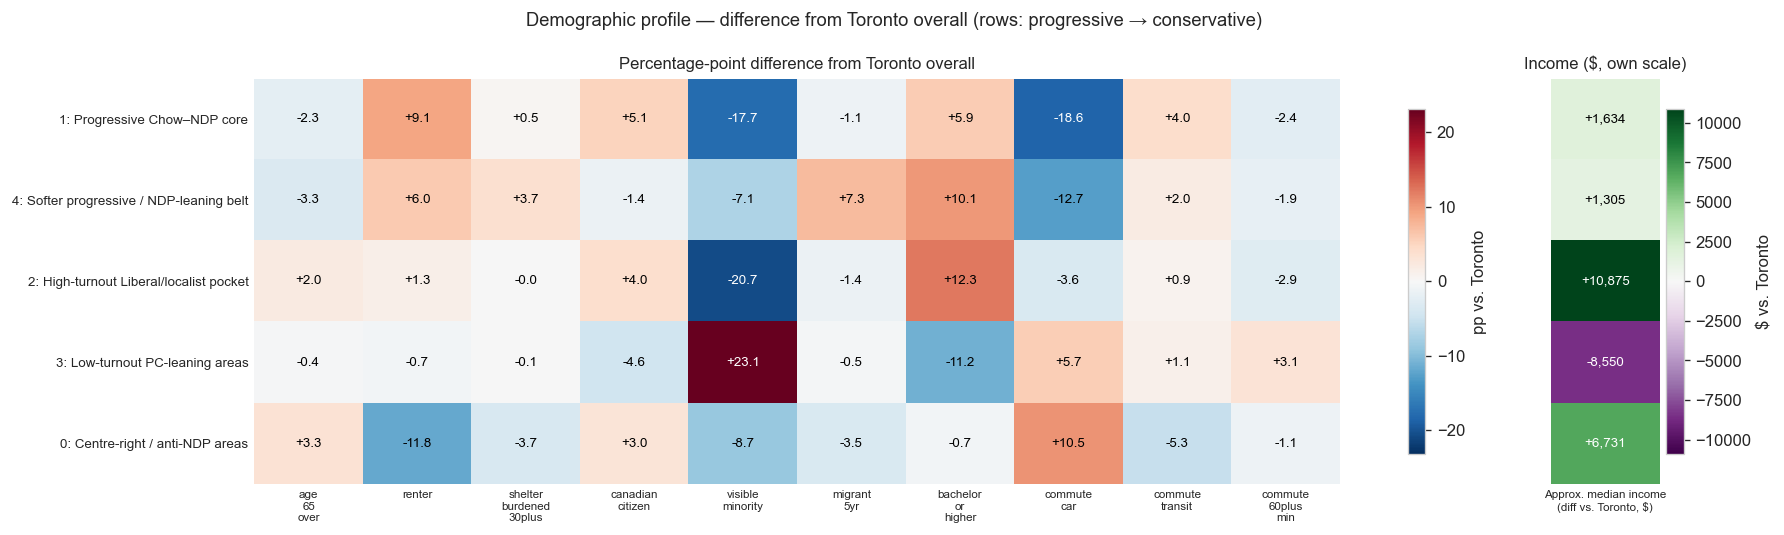

In [43]:
# ── Demographic heatmap: cluster deviation from Toronto ───────────────────────────
# Percentage-point variables and the income measure are on different scales (pp vs. dollars),
# so income gets its own colour-normalised column rather than being forced onto the pp scale.
pct_vars = ["pct_age_65_over", "pct_renter", "pct_shelter_burdened_30plus", "pct_canadian_citizen",
            "pct_visible_minority", "pct_migrant_5yr", "pct_bachelor_or_higher",
            "pct_commute_car", "pct_commute_transit", "pct_commute_60plus_min"]
other_vars = ["pop_density_per_km2", "avg_age", "avg_household_size", "median_income_approx"]

heat_pct = pd.DataFrame({v: comparison_frames[v]["diff_vs_toronto"] for v in pct_vars})
heat_pct.index = [f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)]
heat_pct = heat_pct.loc[[f"{c}: {CLUSTER_LABELS[c]}" for c in DISPLAY_ORDER]]

heat_income = pd.DataFrame({"Approx. median income\n(diff vs. Toronto, $)": comparison_frames["median_income_approx"]["diff_vs_toronto"]})
heat_income.index = heat_pct.index

fig, (ax_pct, ax_income) = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [len(pct_vars), 1]})
vmax = np.abs(heat_pct.values).max()
im1 = ax_pct.imshow(heat_pct.values, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
for i in range(heat_pct.shape[0]):
    for j in range(heat_pct.shape[1]):
        val = heat_pct.values[i, j]
        txt_color = "white" if abs(val) / vmax > 0.6 else "black"
        ax_pct.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=8, color=txt_color)
ax_pct.set_xticks(range(len(pct_vars))); ax_pct.set_xticklabels([v.replace("pct_", "").replace("_", "\n") for v in pct_vars], fontsize=7)
ax_pct.set_yticks(range(len(heat_pct))); ax_pct.set_yticklabels(heat_pct.index, fontsize=8)
ax_pct.set_title("Percentage-point difference from Toronto overall", fontsize=10)

vmax_income = np.abs(heat_income.values).max()
im2 = ax_income.imshow(heat_income.values, cmap="PRGn", aspect="auto", vmin=-vmax_income, vmax=vmax_income)
for i in range(heat_income.shape[0]):
    val = heat_income.values[i, 0]
    txt_color = "white" if abs(val) / vmax_income > 0.6 else "black"
    ax_income.text(0, i, f"{val:+,.0f}", ha="center", va="center", fontsize=8, color=txt_color)
ax_income.set_xticks([0]); ax_income.set_xticklabels(heat_income.columns, fontsize=7)
ax_income.set_yticks([])
ax_income.set_title("Income ($, own scale)", fontsize=10)

# imshow heatmaps otherwise pick up the notebook-wide seaborn "whitegrid" style, which draws
# grid lines straight through the annotated cells — turn grids/ticks/spines off explicitly.
for ax in (ax_pct, ax_income):
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.colorbar(im1, ax=ax_pct, label="pp vs. Toronto", shrink=0.85)
fig.colorbar(im2, ax=ax_income, label="$ vs. Toronto", shrink=0.85)
fig.suptitle("Demographic profile — difference from Toronto overall (rows: progressive → conservative)", fontsize=11)
plt.tight_layout()
plt.show()


**Reading this.** The clearest, most consistent pattern in this heatmap is **visible minority
share**, and it cuts in a specific direction: the progressive core and Liberal/localist pocket
sit far *below* the Toronto average, while the low-turnout PC-leaning group (the largest
cluster) sits far *above* it. We report this because it is a real, large pattern in the
aggregate tract data — but we are deliberately neutral about what it means: it is an
ecological, tract-level association alongside a political-lean pattern, not a claim about how
anyone voted or why, and that cluster's other distinguishing features (below-average
post-secondary attainment, below-average approximate income in the panel to the right,
above-average car commuting) describe a broader outer-suburban profile that visible-minority
share is only one part of. Beyond that: renter share and bachelor's-attainment move together
with the progressive-leaning clusters (all three sit above the city average on both), and
car-commuting is the mirror image, running highest in the two PC/conservative-leaning clusters.
On income specifically: the Liberal/localist pocket has the highest approximate median income
of the five groups, and the low-turnout PC-leaning group has the lowest — the same cluster that
stands out on visible-minority share also stands out, in the opposite direction, on income.


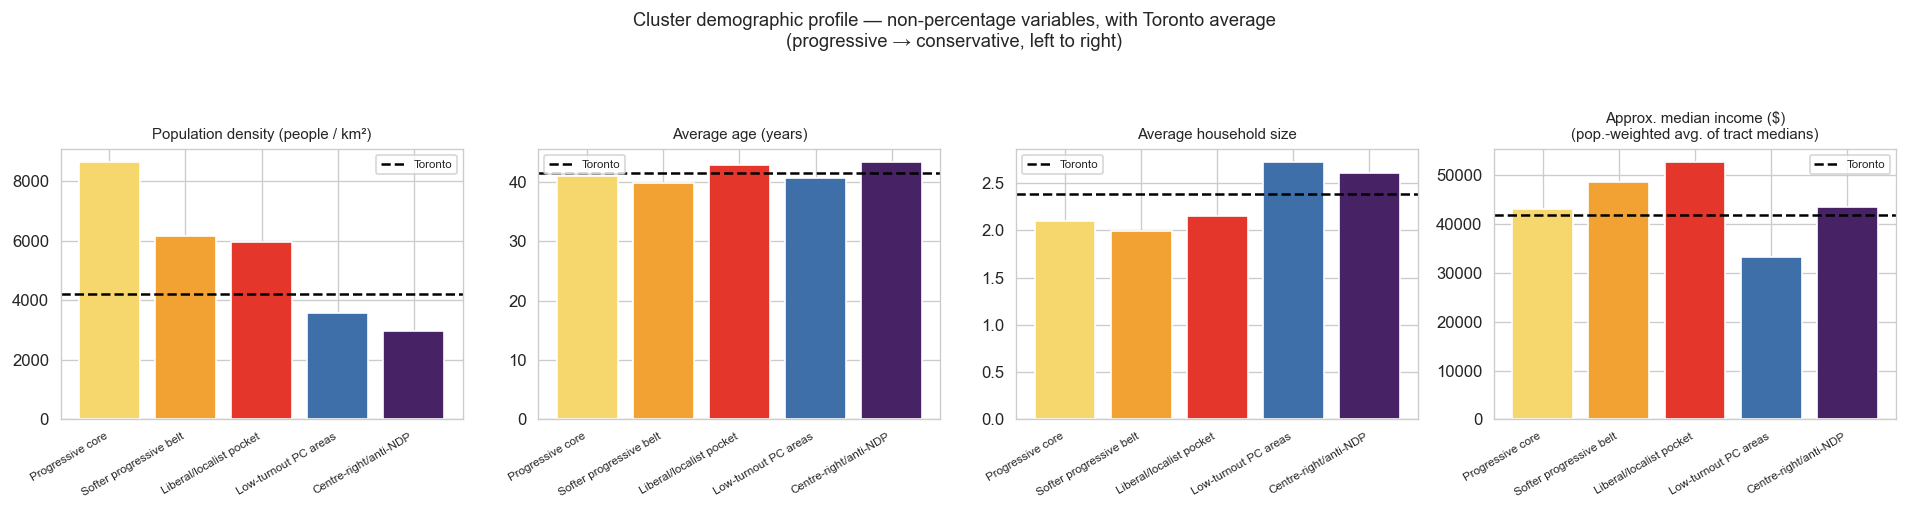

In [44]:
# ── Bar charts for the "other" (non-percentage) variables, each on its own natural scale ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = {"pop_density_per_km2": "Population density (people / km²)", "avg_age": "Average age (years)",
          "avg_household_size": "Average household size", "median_income_approx": "Approx. median income ($)\n(pop.-weighted avg. of tract medians)"}
for ax, col in zip(axes, other_vars):
    vals = cluster_demo.loc[DISPLAY_ORDER, col]
    ax.bar(range(K_CHOSEN), vals.values, color=[PALETTE_BY_ID[c] for c in DISPLAY_ORDER])
    ax.axhline(toronto_row[col], color="black", lw=1.5, linestyle="--", label="Toronto")
    ax.set_xticks(range(K_CHOSEN)); ax.set_xticklabels([CLUSTER_SHORT_LABELS[c] for c in DISPLAY_ORDER], rotation=30, ha="right", fontsize=7)
    ax.set_title(titles[col], fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("Cluster demographic profile — non-percentage variables, with Toronto average\n(progressive → conservative, left to right)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


**Reading this.** The progressive core is by a wide margin the densest group (~8,200
people/km², roughly double the citywide average) and has the smallest average household size —
a compact, high-density inner-city profile. The low-turnout PC-leaning group and the
centre-right/anti-NDP group are the two least-dense groups, both below the citywide average,
consistent with §5's map showing them anchored in the outer and central-north parts of the
city. On income: the Liberal/localist pocket has the highest approximate median income of the
five groups (~$52k vs. a citywide ~$42k), while the low-turnout PC-leaning group has the lowest
(~$34k) alongside the largest average household size — again, remembering that
`median_income_approx` is the population-weighted average of published tract medians (caveat
above), not a recomputed true cluster median. Average age is fairly flat across all five
groups, sitting within about two years of the citywide average in every case — age is not a
strong differentiator here, unlike density, income, or renter share.


## 8. Tract-Level Political Lean vs. Demographics

The cluster-level tables above average away a lot of tract-to-tract variation. Here we look
directly at the 585 tracts, relating a small set of **political lean measures** to demographic
variables. This is a **descriptive, ecological (tract-level) correlation exercise only**: it
says nothing about how any individual voted, and correlation here is not evidence of causation
in either direction.

### Defining the lean measures

City-relative deviations for different parties/candidates aren't automatically comparable,
because their citywide baselines differ hugely — federal NDP's citywide share is 6.4%, so its
pp deviations range over a much narrower band than provincial NDP's, whose citywide share is
23.3%. Averaging *raw* pp deviations would let the highest-baseline election dominate a
composite score. So every lean measure below is built the same way:

1. Take each column's **city-relative deviation** (tract minus citywide, in vote-share units —
   the `_vs_city` columns already computed in §2).
2. **Standardize** each column across all 585 tracts (z-score: subtract the column mean,
   divide by its standard deviation).
3. **Average** the standardized columns that make up the measure.

This gives every underlying election equal say in the composite, regardless of how large that
party's citywide baseline (and therefore its raw pp range) happens to be.

- **Chow/NDP lean** = mean of standardized (`mun_chow_vs_city`, `prov_ndp_vs_city`, `fed_ndp_vs_city`)
- **PC/Conservative lean** = mean of standardized (`prov_pc_vs_city`, `fed_conservative_vs_city`)
  — Bailão is left out of this measure: her 2023 mayoral run doesn't map onto a PC/Conservative
  ballot line as directly as the provincial PC and federal Conservative votes do, and including
  her would mix a candidate-specific race into a two-election party-line composite.
- **Liberal/localist lean** = mean of standardized (`prov_liberal_vs_city`, `fed_liberal_vs_city`,
  `mun_matlow_vs_city`) — explicitly the most heterogeneous of the three, mixing two party votes
  with one candidate's municipal result, because that mix is exactly what the reference
  notebook's §9B diagnosis says defines this cluster. Read it as "how localist/Liberal-leaning",
  not as a clean single-party measure.


In [45]:
def standardized_lean(df, cols):
    z = (df[cols] - df[cols].mean()) / df[cols].std()
    return z.mean(axis=1)

tracts["chow_ndp_lean"]      = standardized_lean(tracts, ["mun_chow_vs_city", "prov_ndp_vs_city", "fed_ndp_vs_city"])
tracts["pc_con_lean"]        = standardized_lean(tracts, ["prov_pc_vs_city", "fed_conservative_vs_city"])
tracts["liberal_localist_lean"] = standardized_lean(tracts, ["prov_liberal_vs_city", "fed_liberal_vs_city", "mun_matlow_vs_city"])
tracts["avg_turnout_pct"] = 100 * tracts[TURNOUT_COLS].mean(axis=1)

print("Lean measures by cluster mean (standardized units; 0 = citywide average, roughly +/-1 = 1 SD):")
tracts.groupby("cluster_8f")[["chow_ndp_lean", "pc_con_lean", "liberal_localist_lean"]].mean().loc[DISPLAY_ORDER].round(2)


Lean measures by cluster mean (standardized units; 0 = citywide average, roughly +/-1 = 1 SD):


,chow_ndp_lean,pc_con_lean,liberal_localist_lean
cluster_8f,,,
1,1.59,-1.42,-0.06
4,0.61,-0.73,-0.07
2,-0.40,-0.20,1.04
3,-0.33,0.42,-0.12
0,-0.81,0.93,-0.21


In [46]:
# ── Merge in the per-tract demographic variables used in the scatterplots below ──
scatter_df = tracts.merge(
    ct_census[["ct_id", "pop_2021", "area_km2", "housing_tenure_renter", "housing_tenure_total",
               "education_bachelor_higher", "education_total", "commute_mode_car_truck_van",
               "commute_mode_transit", "commute_mode_total", "visible_minority_yes",
               "visible_minority_total", "age_65_over_count", "income_total_median"]],
    on="ct_id", how="left", suffixes=("", "_census"),
)
scatter_df["pct_renter"] = 100 * scatter_df["housing_tenure_renter"] / scatter_df["housing_tenure_total"]
scatter_df["pct_bachelor_or_higher"] = 100 * scatter_df["education_bachelor_higher"] / scatter_df["education_total"]
scatter_df["pct_commute_car"] = 100 * scatter_df["commute_mode_car_truck_van"] / scatter_df["commute_mode_total"]
scatter_df["pct_commute_transit"] = 100 * scatter_df["commute_mode_transit"] / scatter_df["commute_mode_total"]
scatter_df["pct_visible_minority"] = 100 * scatter_df["visible_minority_yes"] / scatter_df["visible_minority_total"]
scatter_df["pct_age_65_over"] = 100 * scatter_df["age_65_over_count"] / scatter_df["pop_2021"]
scatter_df["pop_density"] = scatter_df["pop_2021"] / scatter_df["area_km2"]

def tract_scatter(ax, xcol, ycol, xlabel, ylabel, title, logx=False, trend=True, zero_line=False):
    x, y, c = scatter_df[xcol], scatter_df[ycol], scatter_df["cluster_8f"]
    ax.scatter(x, y, c=[PALETTE_BY_ID[v] for v in c], s=12, alpha=0.45, linewidths=0)
    if zero_line:
        ax.axhline(0, color="black", lw=0.8, linestyle=":")
    if trend:
        valid = x.notna() & y.notna()
        xv = np.log10(x[valid]) if logx else x[valid]
        m, b = np.polyfit(xv, y[valid], 1)
        xs = np.linspace(xv.min(), xv.max(), 50)
        ax.plot(10 ** xs if logx else xs, m * xs + b, color="black", lw=1.5, linestyle="--")
    if logx:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=9)

legend_handles = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_SHORT_LABELS[c]}") for c in DISPLAY_ORDER]


### Chow/NDP lean vs. renter share, density, and education

Dashed lines are simple ordinary-least-squares fits across all 585 tracts (density on a log
x-axis, since density is heavily right-skewed) — included to summarize direction and
steepness, not to claim a precise or causal slope.


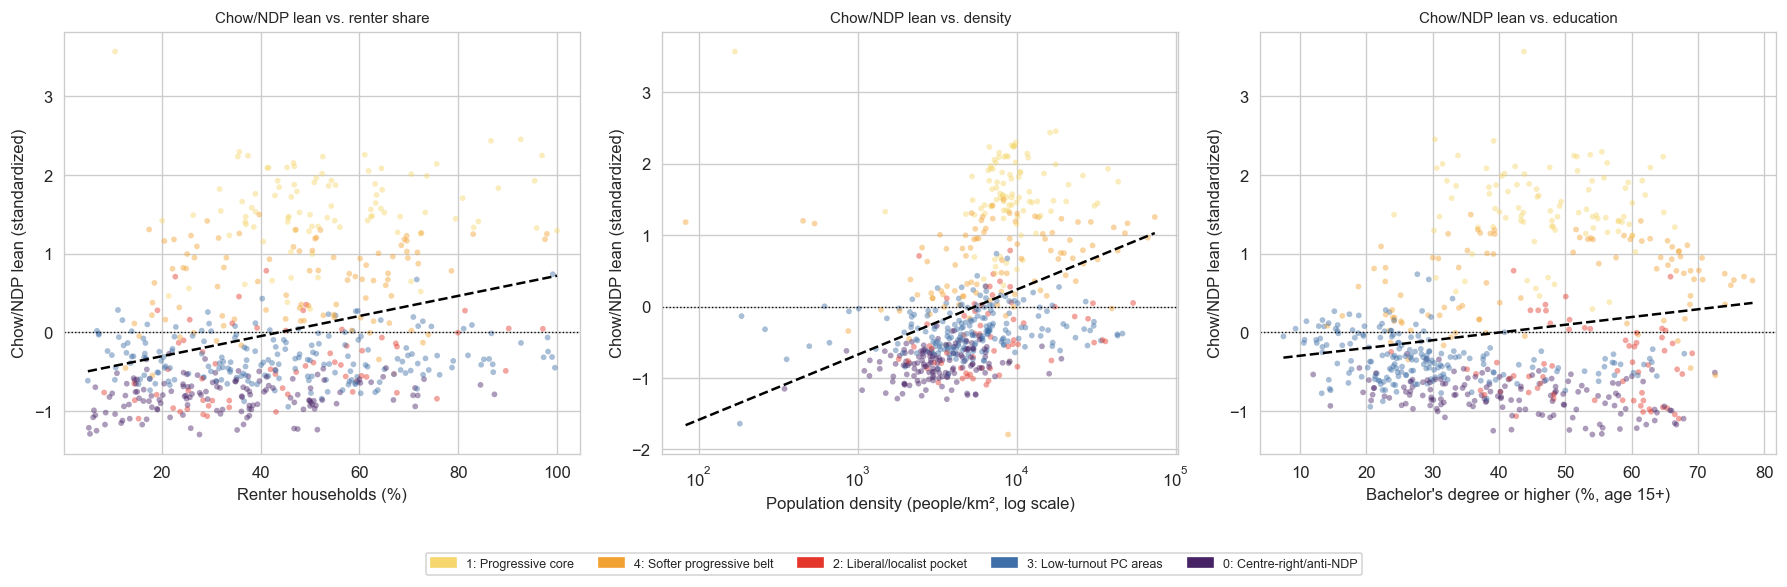

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tract_scatter(axes[0], "pct_renter", "chow_ndp_lean", "Renter households (%)", "Chow/NDP lean (standardized)",
              "Chow/NDP lean vs. renter share", zero_line=True)
tract_scatter(axes[1], "pop_density", "chow_ndp_lean", "Population density (people/km², log scale)", "Chow/NDP lean (standardized)",
              "Chow/NDP lean vs. density", logx=True, zero_line=True)
tract_scatter(axes[2], "pct_bachelor_or_higher", "chow_ndp_lean", "Bachelor's degree or higher (%, age 15+)", "Chow/NDP lean (standardized)",
              "Chow/NDP lean vs. education", zero_line=True)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


**Reading this.** All three panels slope the same way: tracts with more renters, higher
density, and more bachelor's-or-higher attainment tend to show a stronger Chow/NDP lean. The
relationship is clearest at the extremes (very low-renter, low-density, low-education tracts
sit almost entirely below the zero line; the reverse extreme sits almost entirely above it) and
noisier in the middle range, where all five clusters' colours mix. Treat the trend line as "a
tendency across the city," not a rule that holds tract-by-tract.


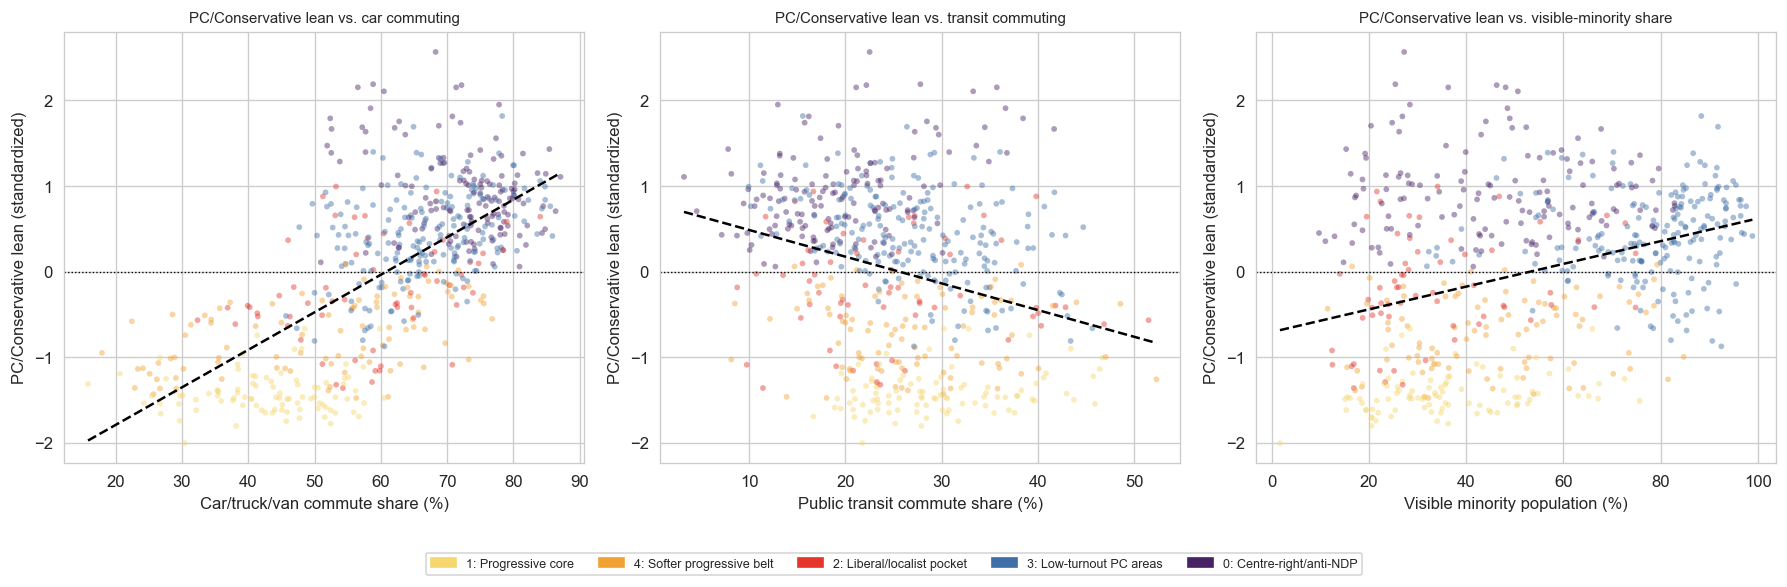

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tract_scatter(axes[0], "pct_commute_car", "pc_con_lean", "Car/truck/van commute share (%)", "PC/Conservative lean (standardized)",
              "PC/Conservative lean vs. car commuting", zero_line=True)
tract_scatter(axes[1], "pct_commute_transit", "pc_con_lean", "Public transit commute share (%)", "PC/Conservative lean (standardized)",
              "PC/Conservative lean vs. transit commuting", zero_line=True)
tract_scatter(axes[2], "pct_visible_minority", "pc_con_lean", "Visible minority population (%)", "PC/Conservative lean (standardized)",
              "PC/Conservative lean vs. visible-minority share", zero_line=True)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


**Reading this.** Car-commuting and PC/Conservative lean move together; transit-commuting and
PC/Conservative lean move in opposite directions — both consistent with §7's finding that the
PC-leaning clusters are the least-dense, most car-dependent groups. The third panel is the
sensitive one: visible-minority share and PC/Conservative lean show a positive association
across these tracts, driven substantially by the low-turnout PC-leaning cluster (§7) sitting
well above the city average on both. We state this as an ecological, tract-level pattern in
this specific dataset — not a claim about any individual's vote, not a causal claim in either
direction, and not a claim that generalizes beyond Toronto's 2023–2025 elections.


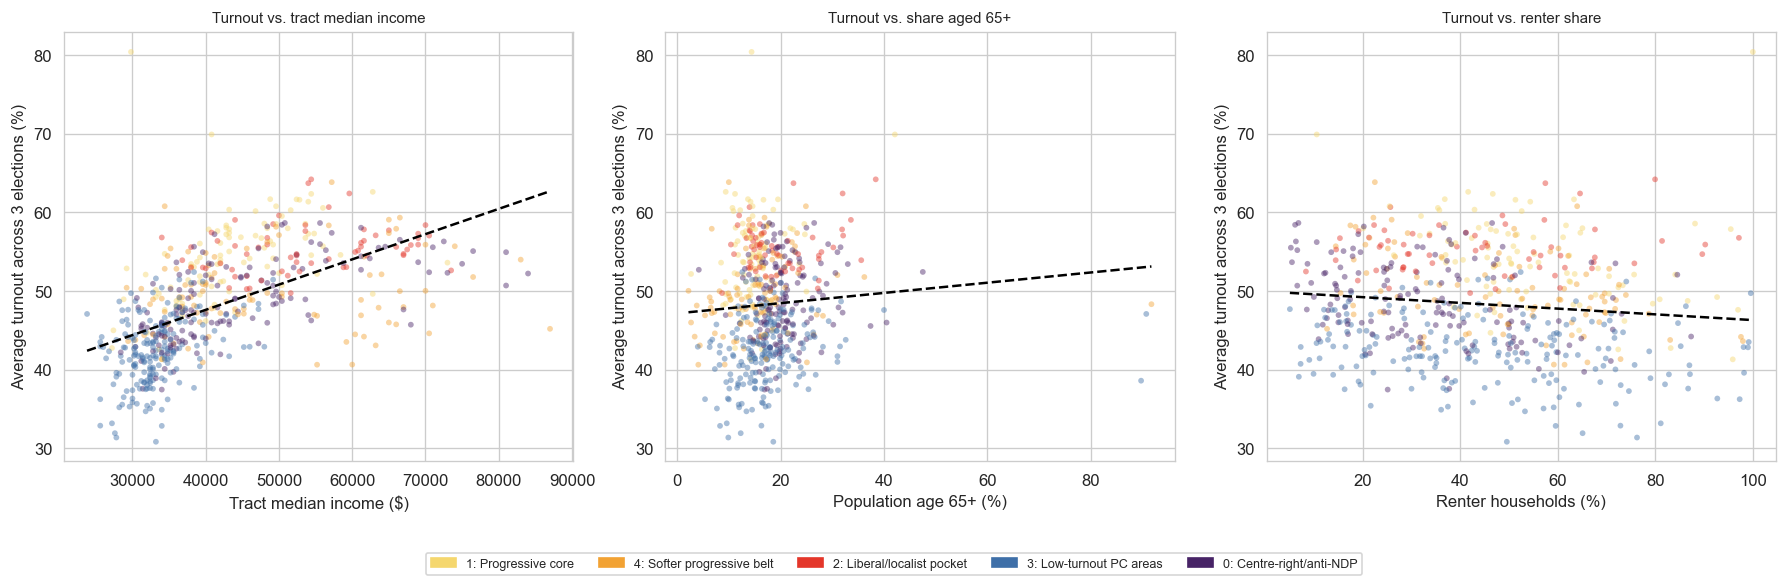

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tract_scatter(axes[0], "income_total_median", "avg_turnout_pct", "Tract median income ($)", "Average turnout across 3 elections (%)",
              "Turnout vs. tract median income")
tract_scatter(axes[1], "pct_age_65_over", "avg_turnout_pct", "Population age 65+ (%)", "Average turnout across 3 elections (%)",
              "Turnout vs. share aged 65+")
tract_scatter(axes[2], "pct_renter", "avg_turnout_pct", "Renter households (%)", "Average turnout across 3 elections (%)",
              "Turnout vs. renter share")
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


**Reading this.** Turnout rises with income and with the share of a tract aged 65+ — both
familiar patterns in turnout research generally, not something specific to this model — and
falls as renter share rises. The renter-share panel is the steepest of the three and lines up
directly with §7's finding that the lowest-turnout cluster is also a below-average-renter,
below-average-income group living in less dense areas; the age panel is consistent with the
well-documented tendency for older populations to vote at higher rates.


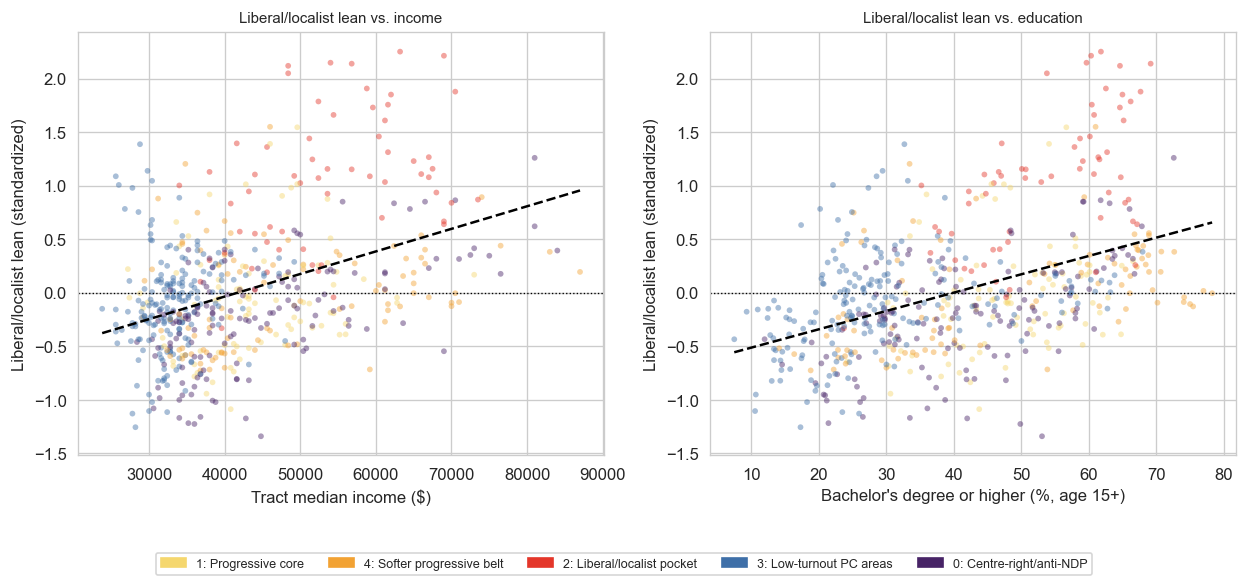

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
tract_scatter(axes[0], "income_total_median", "liberal_localist_lean", "Tract median income ($)", "Liberal/localist lean (standardized)",
              "Liberal/localist lean vs. income", zero_line=True)
tract_scatter(axes[1], "pct_bachelor_or_higher", "liberal_localist_lean", "Bachelor's degree or higher (%, age 15+)", "Liberal/localist lean (standardized)",
              "Liberal/localist lean vs. education", zero_line=True)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


**Reading this.** The Liberal/localist lean rises mildly with both income and education, but
the relationship is visibly weaker and noisier than either the Chow/NDP or PC/Conservative
panels above — the trend lines are flatter, and the Liberal/localist pocket's own tracts (teal)
are scattered across a wide income and education range rather than clustering tightly. That's
consistent with this being the most locally-contingent of the three lean measures (§4, §9B of
the reference notebook): it isn't tracking a single, clean socio-economic gradient the way the
left-right measures do.


## 9. Electoral-Demographic Synthesis

Pulling §3–§8 together into one reference table — the backbone for the eventual article. Each
cell is generated from the actual computed numbers above, not written free-hand, so it stays
in sync if any upstream computation changes. Rows run progressive → conservative.


In [51]:
def political_signature(c):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    over, under = row.nlargest(2), row.nsmallest(2)
    turn_word = "above" if turn > 1 else ("below" if turn < -1 else "near")
    return (f"Over: {', '.join(f'{i} ({v:+.1f}pp)' for i, v in over.items())}. "
            f"Under: {', '.join(f'{i} ({v:+.1f}pp)' for i, v in under.items())}. "
            f"Turnout {turn_word} city average ({turn:+.1f}pp avg. across 3 elections).")

def demographic_signature(c, top_n=3):
    all_vars = pct_vars + other_vars
    spread = {v: (cluster_demo[v].max() - cluster_demo[v].min()) or np.nan for v in all_vars}
    z = pd.Series({v: (cluster_demo.loc[c, v] - toronto_row[v]) / spread[v] for v in all_vars})
    top = z.abs().sort_values(ascending=False).head(top_n).index
    parts = []
    for v in top:
        diff = cluster_demo.loc[c, v] - toronto_row[v]
        direction = "above" if diff > 0 else "below"
        label = "median income (approx.)" if v == "median_income_approx" else v.replace("pct_", "").replace("_", " ")
        parts.append(f"{label} {direction} city avg. ({diff:+.1f})")
    return "; ".join(parts)

def top_geography(c, share_of_cluster, label):
    col = f"{c}: {CLUSTER_LABELS[c]}"
    top = share_of_cluster[col].sort_values(ascending=False).head(2)
    return f"{label}: " + ", ".join(f"{g} ({p:.0f}%)" for g, p in top.items())

CAVEATS = {
    0: "Turnout close to city average; distinguished mainly by partisan lean, not engagement.",
    1: "Highest turnout of the five groups in every election alongside the strongest NDP/Chow lean — "
       "engagement and progressive lean move together here, so the two are hard to fully separate.",
    2: "Partly shaped by a concentrated Matlow showing in specific 2023 municipal results (see reference "
       "notebook §9B); read as a genuine local/Liberal pattern, but with a local-candidate-effect caveat.",
    3: "The largest cluster and the softest boundary in the model (closest centroid to Cluster 0, §4) — "
       "turnout is the clearest distinguishing feature, not partisan intensity. Also the cluster with the "
       "starkest demographic contrast on visible-minority share and income — reported neutrally (§7-§8), "
       "not as an explanation for its politics.",
    4: "A lower-intensity mirror of Cluster 1: same directional lean, smaller magnitude, average turnout.",
}

synthesis_rows = []
for c in DISPLAY_ORDER:
    synthesis_rows.append({
        "cluster": c, "label": CLUSTER_LABELS[c], "n_tracts": int(cluster_sizes_8f[c]),
        "political_signature": political_signature(c),
        "demographic_signature": demographic_signature(c),
        "geography": top_geography(c, ward_share_of_cluster, "Wards") + " | " + top_geography(c, prov_share_of_cluster, "Prov. ridings"),
        "caveat": CAVEATS[c],
    })
synthesis_table = pd.DataFrame(synthesis_rows).set_index("cluster")
synthesis_table


,label,n_tracts,political_signature,demographic_signature,geography,caveat
cluster,,,,,,
1,Progressive Chow–NDP core,92,"Over: prov_ndp (+30.1pp), mun_chow (+17.0pp). ...",pop density per km2 above city avg. (+4446.7);...,"Wards: Ward 14 (21%), Ward 4 (20%) | Prov. rid...",Highest turnout of the five groups in every el...
4,Softer progressive / NDP-leaning belt,94,"Over: prov_ndp (+16.4pp), mun_chow (+4.3pp). U...",migrant 5yr above city avg. (+7.3); avg househ...,"Wards: Ward 20 (18%), Ward 10 (15%) | Prov. ri...",A lower-intensity mirror of Cluster 1: same di...
2,High-turnout Liberal/localist pocket,62,"Over: prov_liberal (+12.3pp), mun_matlow (+5.0...",median income (approx.) above city avg. (+1087...,"Wards: Ward 12 (21%), Ward 15 (16%) | Prov. ri...",Partly shaped by a concentrated Matlow showing...
3,Low-turnout PC-leaning areas,197,"Over: prov_pc (+9.0pp), mun_other (+5.5pp). Un...",visible minority above city avg. (+23.1); comm...,"Wards: Ward 23 (11%), Ward 7 (10%) | Prov. rid...",The largest cluster and the softest boundary i...
0,Centre-right / anti-NDP areas,140,"Over: prov_pc (+12.9pp), fed_conservative (+10...",commute transit below city avg. (-5.3); renter...,"Wards: Ward 2 (17%), Ward 3 (12%) | Prov. ridi...",Turnout close to city average; distinguished m...


*Cross-checked against §5's map/small-multiples and §7's heatmap: the automated
`demographic_signature` values line up with what those sections show directly (e.g. the
low-turnout PC-leaning cluster's top signal here, visible-minority share, is the same standout
feature the §7 heatmap flags; the progressive core's density figure matches §7's bar chart).
Treat this table as a data-checked starting point for the article's cluster-profile cards, not
final copy — the wording still needs a journalist's pass.*


## 10. Representative and Boundary Tracts

For each cluster: which tracts sit closest to its centroid (the clearest, most archetypal
examples — useful for story anecdotes or interactive map callouts), and which tracts sit almost
equally close to a *different* cluster's centroid (the genuinely ambiguous, boundary cases,
useful for QA and for being upfront about where the model is less confident).


In [52]:
dist_to_centroids = np.linalg.norm(X_pca_8f[:, None, :] - centroids_pca[None, :, :], axis=-1)
dist_df = pd.DataFrame(dist_to_centroids, columns=range(K_CHOSEN))
dist_df["ct_id"] = raw_gdf["ct_id"].values
dist_df["cluster_8f"] = labels_8f
dist_df["dist_to_own_centroid"] = dist_df.apply(lambda r: r[r["cluster_8f"]], axis=1)

def second_nearest(row):
    others = row[[c for c in range(K_CHOSEN) if c != row["cluster_8f"]]]
    return others.idxmin(), others.min()

dist_df[["nearest_other_cluster", "dist_to_nearest_other"]] = dist_df.apply(
    lambda r: pd.Series(second_nearest(r)), axis=1
)
dist_df["margin"] = dist_df["dist_to_nearest_other"] - dist_df["dist_to_own_centroid"]

print("Representative tracts — closest to their own cluster centroid:")
representative = (
    dist_df.sort_values("dist_to_own_centroid")
    .groupby("cluster_8f").head(5)
)
representative["_order"] = representative["cluster_8f"].map(lambda c: CLUSTER_META[c]["order"])
representative = representative.sort_values(["_order", "dist_to_own_centroid"]).drop(columns="_order")
representative["cluster_label"] = representative["cluster_8f"].map(CLUSTER_LABELS)
representative[["ct_id", "cluster_8f", "cluster_label", "dist_to_own_centroid", "margin"]]


Representative tracts — closest to their own cluster centroid:


,ct_id,cluster_8f,cluster_label,dist_to_own_centroid,margin
34,5350026.00,1,Progressive Chow–NDP core,0.353409,0.497750
95,5350073.00,1,Progressive Chow–NDP core,0.353697,0.759802
93,5350072.01,1,Progressive Chow–NDP core,0.359053,0.750718
87,5350066.00,1,Progressive Chow–NDP core,0.381513,0.605538
126,5350099.00,1,Progressive Chow–NDP core,0.383032,0.569585
14,5350011.02,4,Softer progressive / NDP-leaning belt,0.367838,0.392699
15,5350011.03,4,Softer progressive / NDP-leaning belt,0.433352,0.328644
23,5350016.00,4,Softer progressive / NDP-leaning belt,0.449431,0.320568
17,5350012.03,4,Softer progressive / NDP-leaning belt,0.476706,0.332670
13,5350011.01,4,Softer progressive / NDP-leaning belt,0.479109,0.381385


In [53]:
print("Boundary tracts — smallest margin between own cluster and the next-nearest cluster:")
boundary = (
    dist_df.sort_values("margin")
    .head(15)
    [["ct_id", "cluster_8f", "nearest_other_cluster", "dist_to_own_centroid", "dist_to_nearest_other", "margin"]]
    .copy()
)
boundary["cluster_label"] = boundary["cluster_8f"].map(CLUSTER_LABELS)
boundary["nearest_other_label"] = boundary["nearest_other_cluster"].map(CLUSTER_LABELS)
boundary


Boundary tracts — smallest margin between own cluster and the next-nearest cluster:


,ct_id,cluster_8f,nearest_other_cluster,dist_to_own_centroid,dist_to_nearest_other,margin,cluster_label,nearest_other_label
464,5350333.00,4,0.0,0.903402,0.901685,-0.001717,Softer progressive / NDP-leaning belt,Centre-right / anti-NDP areas
384,5350300.03,3,2.0,0.684221,0.683313,-0.000908,Low-turnout PC-leaning areas,High-turnout Liberal/localist pocket
313,5350250.01,0,3.0,0.704630,0.706753,0.002123,Centre-right / anti-NDP areas,Low-turnout PC-leaning areas
11,5350010.01,4,1.0,0.791630,0.794042,0.002412,Softer progressive / NDP-leaning belt,Progressive Chow–NDP core
443,5350318.01,3,0.0,0.649360,0.656240,0.006880,Low-turnout PC-leaning areas,Centre-right / anti-NDP areas
402,5350306.01,0,3.0,0.839820,0.849069,0.009249,Centre-right / anti-NDP areas,Low-turnout PC-leaning areas
482,5350346.02,3,4.0,0.775685,0.786117,0.010432,Low-turnout PC-leaning areas,Softer progressive / NDP-leaning belt
249,5350209.00,3,0.0,0.774918,0.789427,0.014509,Low-turnout PC-leaning areas,Centre-right / anti-NDP areas
199,5350167.02,2,1.0,0.969067,0.984567,0.015499,High-turnout Liberal/localist pocket,Progressive Chow–NDP core
170,5350136.02,4,2.0,0.942604,0.959606,0.017002,Softer progressive / NDP-leaning belt,High-turnout Liberal/localist pocket


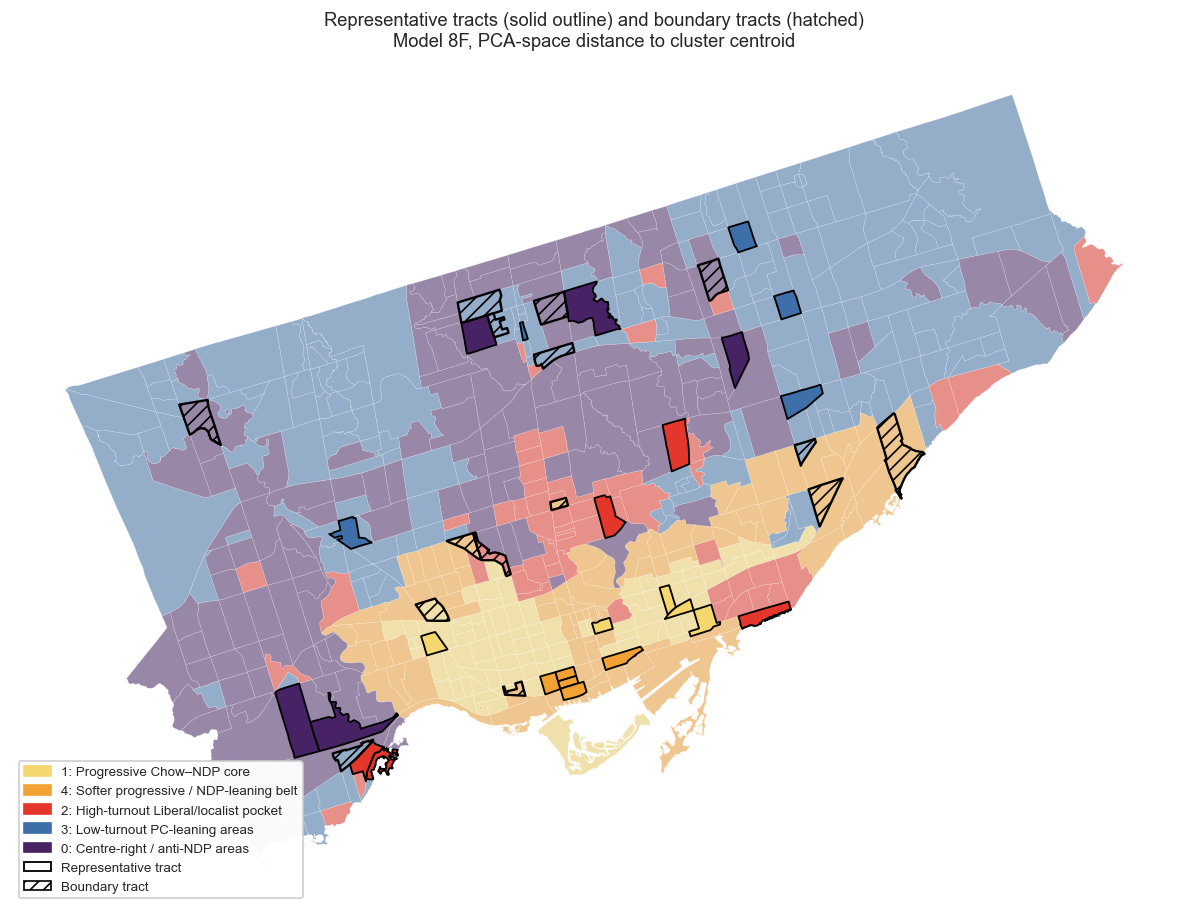

In [54]:
# ── Map: representative tracts (solid) vs. boundary tracts (hatched) ─────────────
fig, ax = plt.subplots(figsize=(10, 11))
tracts.plot(ax=ax, color="#ececec", edgecolor="white", linewidth=0.2)
cmap_8f = mcolors.ListedColormap([PALETTE_BY_ID[c] for c in range(K_CHOSEN)])
tracts.plot(column="cluster_8f", ax=ax, categorical=True, cmap=cmap_8f, edgecolor="white", linewidth=0.2, alpha=0.5)
rep_geo = tracts[tracts["ct_id"].isin(representative["ct_id"])]
rep_geo.plot(ax=ax, color=[PALETTE_BY_ID[c] for c in rep_geo["cluster_8f"]], edgecolor="black", linewidth=1.1)
bnd_geo = tracts[tracts["ct_id"].isin(boundary["ct_id"])]
bnd_geo.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.4, hatch="///")
handles = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}") for c in DISPLAY_ORDER] + [
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.1, label="Representative tract"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Boundary tract"),
]
ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.95)
ax.set_title("Representative tracts (solid outline) and boundary tracts (hatched)\nModel 8F, PCA-space distance to cluster centroid", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()


**Reading this.** The representative tracts broadly match each cluster's ward/riding profile
from §5: the centre-right/anti-NDP group's textbook tracts sit in the central-north and
southwest-lakeshore areas that dominate its ward composition, the low-turnout PC-leaning
group's sit out in the areas it's concentrated in, and the progressive core / Liberal-localist
pocket / softer progressive belt's representative tracts cluster around the downtown/midtown
corridor as expected. The boundary tracts are not scattered randomly — most cluster in two
specific places: along the edge between the centre-right/anti-NDP and low-turnout PC clusters
in the central-north part of the city, and along the edge between the three downtown-adjacent
clusters (progressive core, Liberal/localist pocket, softer progressive belt) where they meet
each other near the core. The first pattern lines up exactly with §4's finding that those two
clusters have the closest centroids of any pair in the model — the map confirms that softest
boundary is a real, geographically contiguous seam, not a modelling artifact scattered across
unrelated tracts.


In [55]:
# The IDs below are fixed by the west->east centroid sort in §2 and re-confirmed there on every
# run (the notebook asserts the reproduction matches the reference profile before proceeding) —
# safe to reference directly by number in the write-up prose that follows. Display order is
# the separate, progressive->conservative ordering from CLUSTER_META, also fixed in §2.
prog_core      = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[1]][0]
soft_prog      = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[4]][0]
centre_right   = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[0]][0]
low_turnout    = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[3]][0]
liberal_pocket = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == PROVISIONAL_LABELS[2]][0]
for c, name in [(prog_core, "Progressive core"), (soft_prog, "Softer progressive belt"),
                (centre_right, "Centre-right/anti-NDP"), (low_turnout, "Low-turnout PC-leaning"),
                (liberal_pocket, "Liberal/localist pocket")]:
    print(f"{name}: Cluster ID {c}, display order {CLUSTER_META[c]['order']} "
          f"(0 = most progressive, {K_CHOSEN - 1} = most conservative)")


Progressive core: Cluster ID 1, display order 0 (0 = most progressive, 4 = most conservative)
Softer progressive belt: Cluster ID 4, display order 1 (0 = most progressive, 4 = most conservative)
Centre-right/anti-NDP: Cluster ID 0, display order 4 (0 = most progressive, 4 = most conservative)
Low-turnout PC-leaning: Cluster ID 3, display order 3 (0 = most progressive, 4 = most conservative)
Liberal/localist pocket: Cluster ID 2, display order 2 (0 = most progressive, 4 = most conservative)


## 11. Story Implications

### The narrative arc

1. Election-night maps usually show one race at a time — mayor, or the provincial vote, or the
   federal vote — and hide how a tract's political character looks across *all three* at once.
2. Model 8F builds a single profile per tract by comparing it both to Toronto overall and to
   its own ward/riding, then groups tracts with similar profiles.
3. Five political neighbourhood types emerge — not the two-sided "downtown left, suburbs
   right" story Toronto political coverage usually reaches for.
4. **The left side splits in two**: a high-turnout **progressive core** and a softer,
   lower-intensity **NDP-leaning belt** that leans the same direction but far less sharply, at
   closer-to-average turnout.
5. **The right side also splits in two**: a **centre-right/anti-NDP** bloc and a
   **low-turnout PC-leaning** bloc that shares its partisan direction but is set apart mainly
   by being consistently the least-engaged group across all three elections — and, per §4, the
   softest boundary in the whole model.
6. **A fifth group cuts across the left-right frame entirely**: a smaller, high-turnout
   **Liberal/localist pocket** shaped as much by a specific municipal candidate's local
   strength as by ideology — evidence that local context and candidate quality still carve out
   real space on the map, even in a model built purely from ballots.
7. The demographic profiles in §7-§8 (now built directly from tract-level census data, with no
   ADA-to-tract allocation step) describe *who lives in* each political Toronto — read as
   associations, not causes.
8. Throughout: these are **neighbourhood-level profiles of aggregate vote patterns**, not
   descriptions of individual voters, and they reflect a mix of turnout, local candidates,
   riding context, and durable political geography — not any one of those alone.

*(The cell just above prints each named group's underlying `cluster_8f` ID and display order —
re-check that printout if the upstream pipeline is ever re-run with different inputs.)*

### Possible final article visuals

- Main Model 8F cluster map, with and without ward boundaries (§5)
- Cluster profile heatmap — city-relative deviations (§3)
- Actual vote-share heatmap and plain-numbers table (§3)
- Turnout-by-cluster comparison chart (§3)
- "Left side splits in two" map: progressive core + softer progressive belt highlighted against the rest
- "Right side splits in two" map: centre-right/anti-NDP + low-turnout PC-leaning highlighted against the rest
- Demographic deviation-from-Toronto heatmap, including income (§7)
- Political-lean-vs-demographics scatterplots (§8)
- Cluster profile cards, one per group, combining §9's synthesis table with a small map inset
- Cluster composition by ward/riding stacked bar chart (§5)
- Representative-tract examples / boundary-tract map, for interactive callouts (§10)


## 12. Summary: Moving from ADA to Tract-Level (CT) Census Data

This section closes the notebook with a plain-language summary of what changed when the
demographic analysis moved from the ADA census file to the direct tract-level (CT) file, and
what the strongest, most defensible findings are as a result.


In [56]:
top_income_cluster = cluster_demo["median_income_approx"].idxmax()
bottom_income_cluster = cluster_demo["median_income_approx"].idxmin()
top_density_cluster = cluster_demo["pop_density_per_km2"].idxmax()
top_vismin_cluster = cluster_demo["pct_visible_minority"].idxmax()
bottom_vismin_cluster = cluster_demo["pct_visible_minority"].idxmin()

summary_md = f'''
### What changed methodologically

- **Data source:** replaced `census/toronto-ada.csv` (279 Aggregate Dissemination Areas) with
  `census/toronto-ct-small.csv` (622 census tracts, of which 585 are our clustered tracts) —
  the same StatCan characteristic IDs, names, and codes, just published at a finer, and for our
  purposes exactly matching, geography.
- **The join is now exact, not allocated.** The ADA version required disaggregating ADA totals
  down to child tracts by land area for the ~80% of ADAs spanning more than one tract — an
  explicit, clearly-caveated modelling assumption (uniform density within an ADA), but an
  assumption nonetheless. The CT version needs no allocation: every one of the 585 clustered
  tracts has its own directly-published census record, verified 1:1 with no duplicates and no
  unmatched tracts (§6).
- **One caveat was removed; one was not.** The area-weighting caveat is gone entirely. The
  `median_income_approx` caveat remains and always will — published medians are never
  additive, at any geography level, so a population-weighted average of tract medians is still
  only an approximation of a true cluster median.
- **A new caveat appeared in its place:** two tracts (0.3% of 585) have confidentiality-
  suppressed 25%-sample values in the CT file, versus none in the coarser ADA aggregates. This
  is a far smaller and more clearly bounded gap than the allocation assumption it replaced.

### Updated demographic profile, cluster by cluster

- **Highest approximate median income:** {CLUSTER_META[top_income_cluster]['short_label']}
  (~${cluster_demo.loc[top_income_cluster, 'median_income_approx']:,.0f}).
- **Lowest approximate median income:** {CLUSTER_META[bottom_income_cluster]['short_label']}
  (~${cluster_demo.loc[bottom_income_cluster, 'median_income_approx']:,.0f}) — also the largest
  cluster by tract count and population share.
- **Highest population density:** {CLUSTER_META[top_density_cluster]['short_label']}
  ({cluster_demo.loc[top_density_cluster, 'pop_density_per_km2']:,.0f} people/km², roughly
  double the citywide average).
- **Visible-minority share** ranges from {cluster_demo.loc[bottom_vismin_cluster, 'pct_visible_minority']:.0f}%
  ({CLUSTER_META[bottom_vismin_cluster]['short_label']}) to
  {cluster_demo.loc[top_vismin_cluster, 'pct_visible_minority']:.0f}%
  ({CLUSTER_META[top_vismin_cluster]['short_label']}) — reported here, as throughout, as a
  neutral descriptive fact about aggregate tract composition, not an explanation of political
  behaviour.

### Strongest article-ready findings

1. Toronto's political geography splits into five groups, not two — a genuine progressive
   core/belt split and a genuine centre-right/low-turnout split, plus a smaller cross-cutting
   Liberal/localist pocket.
2. Turnout is a real, consistent axis (holding across three separate elections) layered on top
   of — not instead of — a partisan-lean split that is still the primary driver (§4).
3. The demographic data, now on a cleanly-joined tract-level footing, sharpens rather than
   changes the earlier picture: density, renter share, and education track the progressive/
   conservative divide; income and visible-minority share most sharply distinguish the
   low-turnout PC-leaning cluster specifically, in both directions from the Liberal/localist
   pocket.
4. The Liberal/localist pocket remains the model's most spatially fragmented and demographically
   least-predictable group — consistent with it being shaped by local candidate effects (§4,
   §8) rather than a clean socio-economic or ideological profile.

### Remaining caveats

- Median income is always an approximation at the cluster level (see above) — never present it
  as an exact figure.
- Two tracts have suppressed sample-based census values; effect on cluster aggregates is
  negligible but non-zero.
- All demographic-political relationships in §8 are ecological (tract-level) correlations, not
  individual-level claims, and are not causal in either direction.
- This is still a description of a chosen model (8F) — the reference notebook's own sensitivity
  analysis (§9 there) shows the exact cluster boundaries shift somewhat under alternative
  weightings; treat the softest boundary in this model (centre-right/anti-NDP vs. low-turnout
  PC-leaning, §4) as the one most likely to read differently under a different modelling choice.
'''
display(Markdown(summary_md))



### What changed methodologically

- **Data source:** replaced `census/toronto-ada.csv` (279 Aggregate Dissemination Areas) with
  `census/toronto-ct-small.csv` (622 census tracts, of which 585 are our clustered tracts) —
  the same StatCan characteristic IDs, names, and codes, just published at a finer, and for our
  purposes exactly matching, geography.
- **The join is now exact, not allocated.** The ADA version required disaggregating ADA totals
  down to child tracts by land area for the ~80% of ADAs spanning more than one tract — an
  explicit, clearly-caveated modelling assumption (uniform density within an ADA), but an
  assumption nonetheless. The CT version needs no allocation: every one of the 585 clustered
  tracts has its own directly-published census record, verified 1:1 with no duplicates and no
  unmatched tracts (§6).
- **One caveat was removed; one was not.** The area-weighting caveat is gone entirely. The
  `median_income_approx` caveat remains and always will — published medians are never
  additive, at any geography level, so a population-weighted average of tract medians is still
  only an approximation of a true cluster median.
- **A new caveat appeared in its place:** two tracts (0.3% of 585) have confidentiality-
  suppressed 25%-sample values in the CT file, versus none in the coarser ADA aggregates. This
  is a far smaller and more clearly bounded gap than the allocation assumption it replaced.

### Updated demographic profile, cluster by cluster

- **Highest approximate median income:** Liberal/localist pocket
  (~$52,756).
- **Lowest approximate median income:** Low-turnout PC areas
  (~$33,331) — also the largest
  cluster by tract count and population share.
- **Highest population density:** Progressive core
  (8,643 people/km², roughly
  double the citywide average).
- **Visible-minority share** ranges from 35%
  (Liberal/localist pocket) to
  79%
  (Low-turnout PC areas) — reported here, as throughout, as a
  neutral descriptive fact about aggregate tract composition, not an explanation of political
  behaviour.

### Strongest article-ready findings

1. Toronto's political geography splits into five groups, not two — a genuine progressive
   core/belt split and a genuine centre-right/low-turnout split, plus a smaller cross-cutting
   Liberal/localist pocket.
2. Turnout is a real, consistent axis (holding across three separate elections) layered on top
   of — not instead of — a partisan-lean split that is still the primary driver (§4).
3. The demographic data, now on a cleanly-joined tract-level footing, sharpens rather than
   changes the earlier picture: density, renter share, and education track the progressive/
   conservative divide; income and visible-minority share most sharply distinguish the
   low-turnout PC-leaning cluster specifically, in both directions from the Liberal/localist
   pocket.
4. The Liberal/localist pocket remains the model's most spatially fragmented and demographically
   least-predictable group — consistent with it being shaped by local candidate effects (§4,
   §8) rather than a clean socio-economic or ideological profile.

### Remaining caveats

- Median income is always an approximation at the cluster level (see above) — never present it
  as an exact figure.
- Two tracts have suppressed sample-based census values; effect on cluster aggregates is
  negligible but non-zero.
- All demographic-political relationships in §8 are ecological (tract-level) correlations, not
  individual-level claims, and are not causal in either direction.
- This is still a description of a chosen model (8F) — the reference notebook's own sensitivity
  analysis (§9 there) shows the exact cluster boundaries shift somewhat under alternative
  weightings; treat the softest boundary in this model (centre-right/anti-NDP vs. low-turnout
  PC-leaning, §4) as the one most likely to read differently under a different modelling choice.
